<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

# Описание проекта

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 

Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. 

У вас будет несколько **задач. Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника** на основе данных заказчика. 

Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.

Ваша **вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании**.

In [414]:
!pip install imblearn -q
!pip install phik -q

In [415]:
import phik
from imblearn.under_sampling import RandomUnderSampler

In [416]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, 
                                   MinMaxScaler, StandardScaler)
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.metrics import make_scorer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (roc_auc_score)

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler, LabelEncoder


In [417]:
RANDOM_STATE = 42

вспомогательные функции:

In [418]:
def correct_path (csv_name):
    if not os.path.exists(csv_name):
        return '/datasets/' + csv_name
    return csv_name

# визуализирует все категориальные фичи датафрейма в виде пирогов
# визуализирует все категориальные фичи датафрейма в виде ящиков с усами и гистограмм с распределием, выводит descirbe
# поддерживает любое количество фильтров, фильтры поочерёдно применяются к датафрейму как запрос в query(),
#   графики выводятся для каждого фильтра
#   чтобы вывести графики без фильтра нужно передать пустой запрос, или же не передавать фильтры вовсе

def do_eda(df, filters=[]):
    bins=25
    n_filters = len(filters)
    PIE_WIDTH = 5

    # вывод графиков по категориальным фичам 
    for column in df:
        if df[column].dtype == 'O':
            title0 = f"столбец {column}"
            df_show = df[column]
            if n_filters > 0 and filters[0] != '':
                title = title0 + f"\nфильтр: {filters[0]}"
                df_show = df.query(filters[0])[column]
            if n_filters <= 1:
                ax = df_show.value_counts().plot(title=title0, kind='pie', figsize=(PIE_WIDTH, PIE_WIDTH), autopct=lambda x: f"{x:.0f}%");
                ax.set_ylabel('')
            else:
                fig, axes = plt.subplots(1, n_filters, figsize=(PIE_WIDTH*n_filters, PIE_WIDTH))
                for i in range (n_filters):
                    if filters[i] != '':
                        title = title0 + f"\nфильтр: {filters[i]}"
                        df_show = df.query(filters[i])[column]
                    else:
                        title = title0
                    ax = df_show.value_counts().plot(ax=axes[i], title=title, kind='pie', autopct=lambda x: f"{x:.0f}%");
                    ax.set_ylabel('')
        plt.show();

    # вывод графиков по числовым фичам 
    if n_filters == 0:
        filters = ['']
        n_filters = 1
    for column in df:
        if df[column].dtype in ['int64', 'float64'] and column != "id":
            display (f"********** Следующий признак: {column}")
            fig, axs = plt.subplots(nrows=2*max(1, n_filters), ncols=1, figsize=(6, 7*n_filters))
            for i in range (n_filters):
                title = f"столбец {column}"
                df_show = df[column]
                if filters[i] != '':
                    title = title + f", фильтр: {filters[i]}"
                    df_show = df.query(filters[i])[column]
                axs[i*2].boxplot(df_show, vert=False);
                ##v1 sns.boxplot(data=df_show, ax=axs[i*2], palette=['lightsteelblue'], orient='h')
                axs[i*2].set_title(title, fontsize=9)
                sns.histplot(df_show, bins=bins, kde=True, ax=axs[i*2+1], alpha=0.8)
                axs[i*2+1].set_xlabel('')
                display(f"фильтр = '{filters[i]}'")
                display(df_show.describe())
            plt.show();

def def_load_csv(csv):
    df = pd.read_csv(correct_path(csv))
    display(df.info())
    display(df.head())
    return df

# Задача 1: предсказание уровня удовлетворённости сотрудника

<div class="alert alert-secondary" style="background-color:#D9EEE1;color:black;">
Для этой задачи заказчик предоставил данные с признаками:

- id — уникальный идентификатор сотрудника;
- dept — отдел, в котором работает сотрудник;
- level — уровень занимаемой должности;
- workload — уровень загруженности сотрудника;
- employment_years — длительность работы в компании (в годах);
- last_year_promo — показывает, было ли повышение за последний год;
- last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;
- supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;
- salary — ежемесячная зарплата сотрудника;
- job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 1. Загрузка данных

- Тренировочная выборка: train_job_satisfaction_rate.csv
- Входные признаки тестовой выборки: test_features.csv
- Целевой признак тестовой выборки: test_target_job_satisfaction_rate.csv

In [419]:
train_df = def_load_csv ('train_job_satisfaction_rate.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


None

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [420]:
test_X_df = def_load_csv ('test_features.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [421]:
test_y_df = def_load_csv ('test_target_job_satisfaction_rate.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


None

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 2. Предобработка данных
Изучите данные и сделайте выводы. При необходимости выполните предобработку. Если есть пропуски, заполните их в пайплайне.

- В типах данных проблем не обнаружено.
- Имена полей соответствуют camel-нотации.
- 4000 - приемлемый размер обучающей выборки

Изучим пропуски

In [422]:
display(train_df.isna().sum())

id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

In [425]:
test_df = test_X_df.merge(test_y_df, on = 'id', how='left') \
    .reset_index(drop=True)

In [426]:
test_df = test_df.dropna().reset_index(drop=True)
display(test_df)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79
1,686555,hr,junior,medium,1,no,no,4,30000,0.72
2,467458,sales,middle,low,5,no,no,4,19200,0.64
3,418655,sales,middle,low,6,no,no,4,19200,0.60
4,789145,hr,middle,medium,5,no,no,5,40800,0.75
...,...,...,...,...,...,...,...,...,...,...
1992,393147,marketing,junior,low,3,no,no,3,20400,0.56
1993,109582,technology,middle,low,3,no,no,2,21600,0.14
1994,305653,technology,junior,low,1,no,no,3,14400,0.11
1995,160233,technology,middle,low,8,no,no,1,32400,0.43


Изучим явные дубликаты

In [427]:
display(train_df.duplicated().sum())

0

In [428]:
display(test_df.duplicated().sum())

0

Явных дубликатов не найдено.

Изучим неявные дубликаты в датафрейме

In [429]:
def test_implicit_dublicates (df):
    for column in df:
        if df[column].dtype == 'O':
            display(f"столбец {column}")
            display(df[column].value_counts())

test_implicit_dublicates (train_df)

'столбец dept'

sales         1512
technology     866
purchasing     610
marketing      550
hr             456
Name: dept, dtype: int64

'столбец level'

junior    1894
middle    1744
sinior     358
Name: level, dtype: int64

'столбец workload'

medium    2066
low       1200
high       734
Name: workload, dtype: int64

'столбец last_year_promo'

no     3880
yes     120
Name: last_year_promo, dtype: int64

'столбец last_year_violations'

no     3441
yes     559
Name: last_year_violations, dtype: int64

Исправим опечатку, в остальном всё хорошо.

In [430]:
train_df['level'] = train_df['level'].replace('sinior', 'senior')
test_df['level'] = test_df['level'].replace('sinior', 'senior')

In [431]:
test_implicit_dublicates (test_df)

'столбец dept'

sales         762
technology    455
marketing     279
purchasing    273
hr            227
                1
Name: dept, dtype: int64

'столбец level'

junior    972
middle    854
senior    171
Name: level, dtype: int64

'столбец workload'

medium    1041
low        592
high       363
             1
Name: workload, dtype: int64

'столбец last_year_promo'

no     1934
yes      63
Name: last_year_promo, dtype: int64

'столбец last_year_violations'

no     1735
yes     262
Name: last_year_violations, dtype: int64

Удалены неявные пропуски.

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 3. Исследовательский анализ данных
Исследуйте все признаки и сделайте выводы о том, как их нужно подготовить.

Изучим категориальные и количественные значения

Вычислим медиану job_satisfaction_rate - её возьмём в качестве порога разделения удовлетворённости.

In [433]:
train_df

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20
...,...,...,...,...,...,...,...,...,...,...
3995,457950,technology,junior,high,2,no,no,3,46800,0.45
3996,957499,sales,junior,medium,2,no,no,4,21600,0.68
3997,533318,sales,middle,low,7,no,no,5,24000,0.76
3998,706868,sales,junior,medium,2,no,no,3,24000,0.48


Разделим "довльных" и "недовольных" по медиане, исходя из предположения, что разделение людей на 2 половины - наиболее репрезентативно представит характеристики довольных и недовольных.

In [434]:
JOB_SATISFACTION_RATE_MEDIAN = train_df['job_satisfaction_rate'].median()

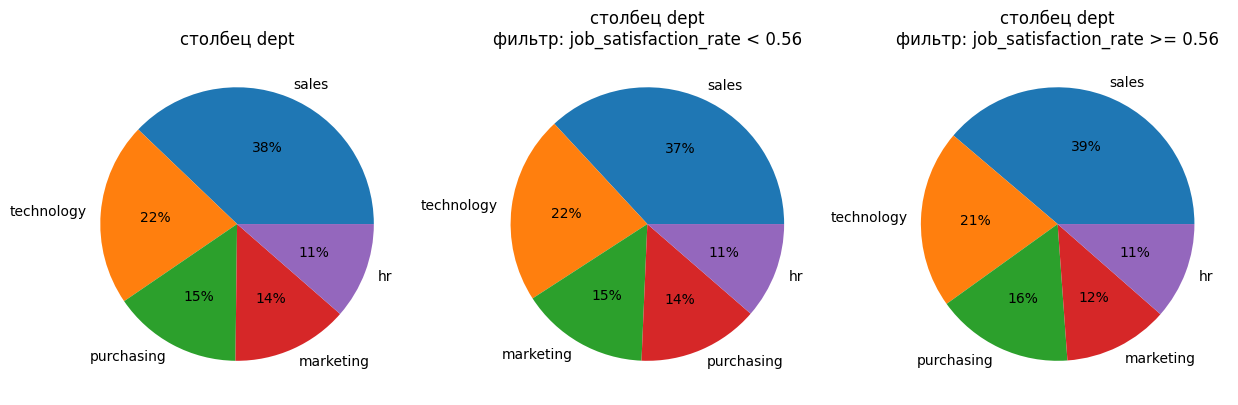

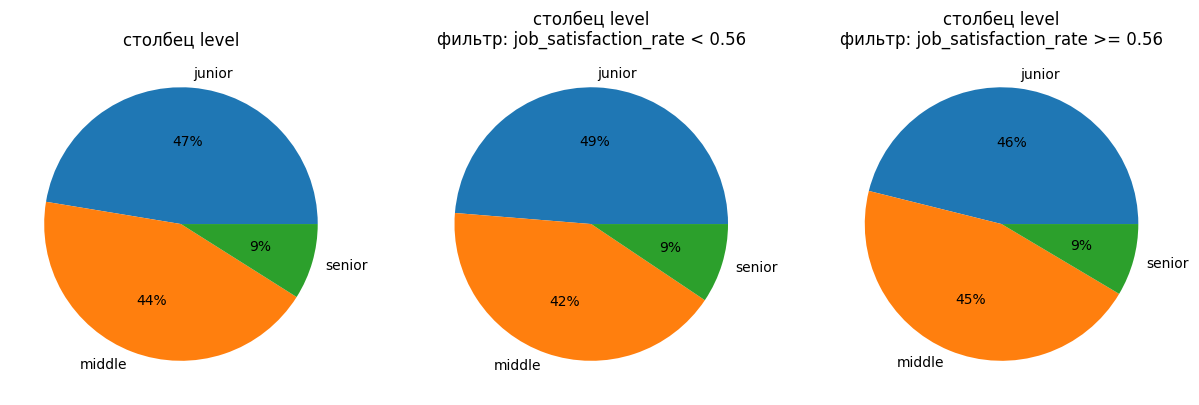

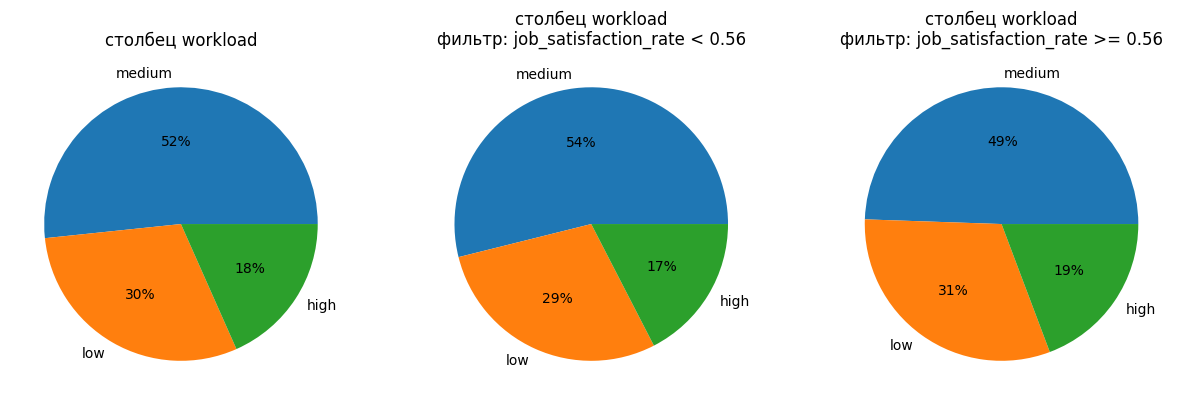

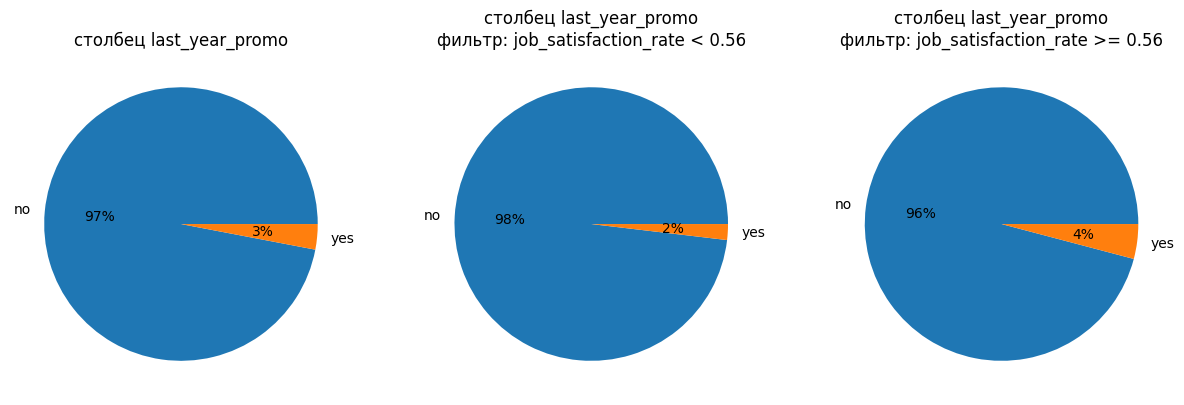

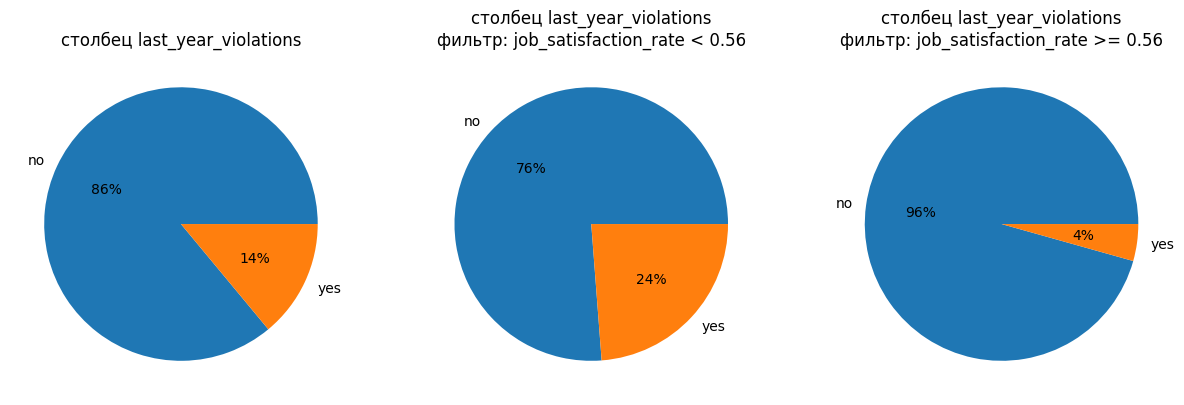

'********** Следующий признак: employment_years'

"фильтр = ''"

count    4000.000000
mean        3.718500
std         2.542513
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64

"фильтр = 'job_satisfaction_rate < 0.56'"

count    1980.000000
mean        3.398990
std         2.443996
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        10.000000
Name: employment_years, dtype: float64

"фильтр = 'job_satisfaction_rate >= 0.56'"

count    2020.000000
mean        4.031683
std         2.598240
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64

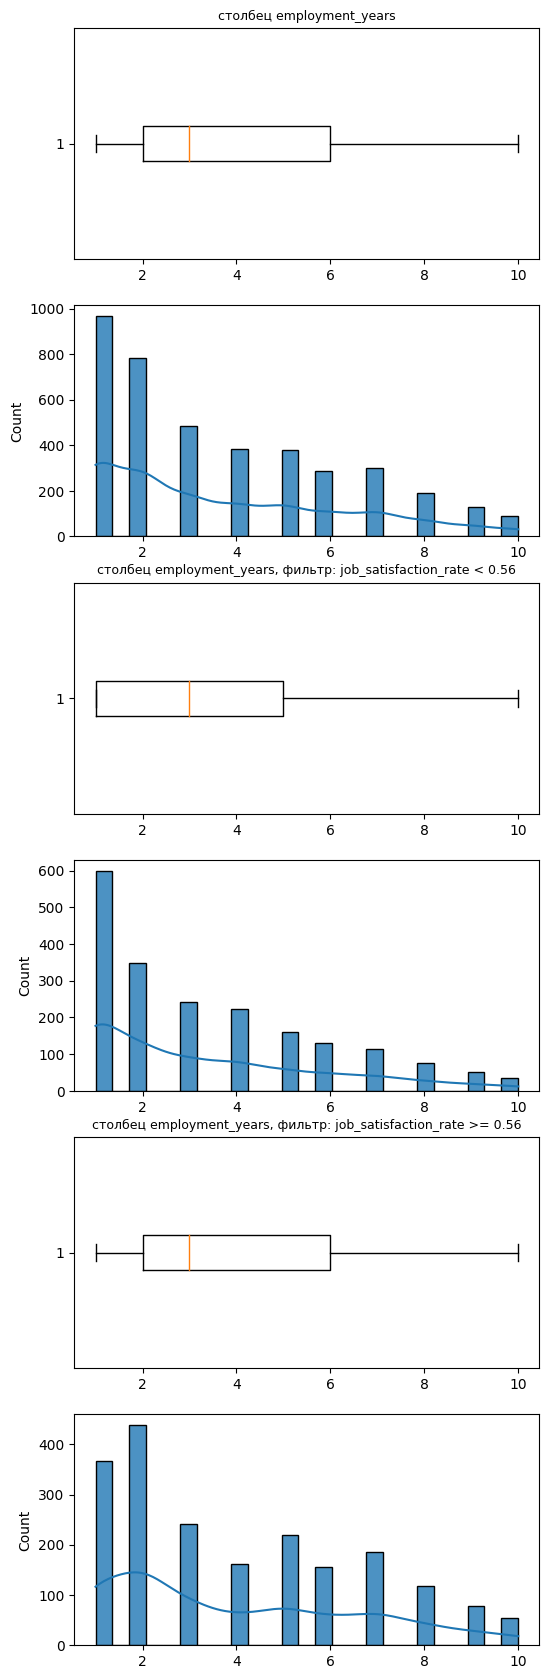

'********** Следующий признак: supervisor_evaluation'

"фильтр = ''"

count    4000.000000
mean        3.476500
std         1.008812
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

"фильтр = 'job_satisfaction_rate < 0.56'"

count    1980.000000
mean        2.797475
std         0.885509
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

"фильтр = 'job_satisfaction_rate >= 0.56'"

count    2020.000000
mean        4.142079
std         0.593102
min         1.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

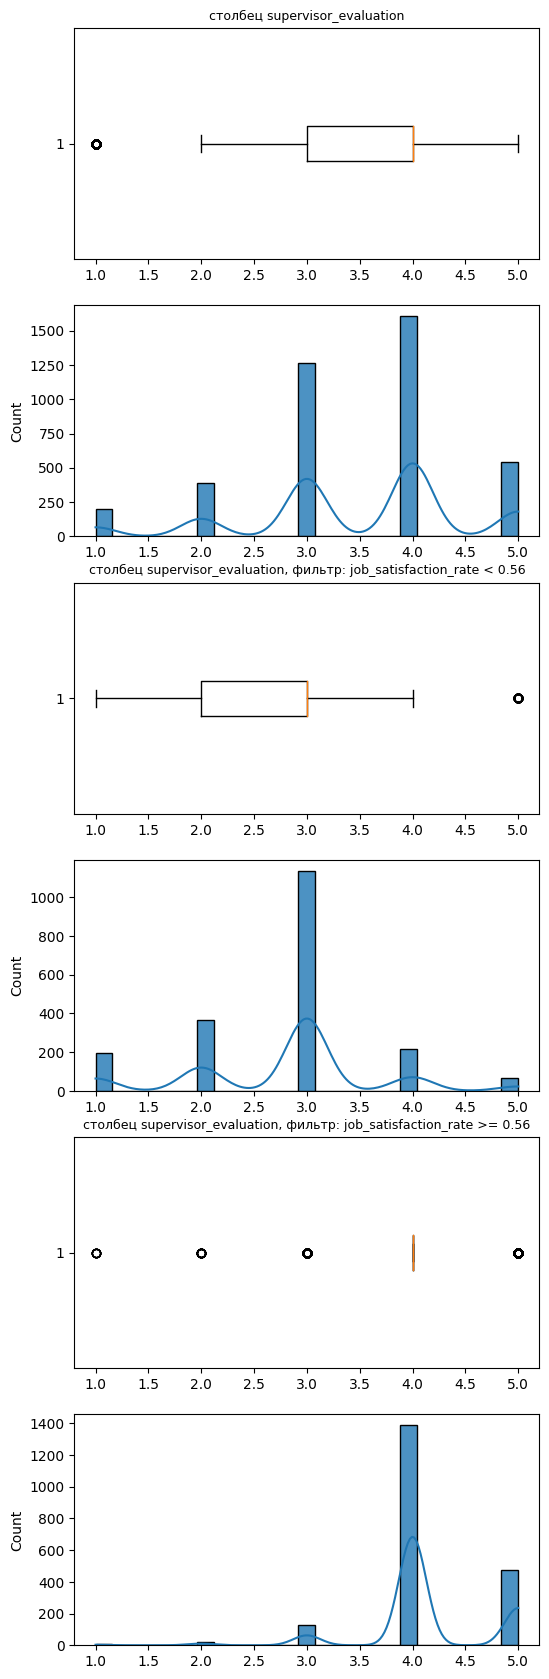

'********** Следующий признак: salary'

"фильтр = ''"

count     4000.000000
mean     33926.700000
std      14900.703838
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      98400.000000
Name: salary, dtype: float64

"фильтр = 'job_satisfaction_rate < 0.56'"

count     1980.000000
mean     32710.909091
std      14531.939425
min      12000.000000
25%      21600.000000
50%      28800.000000
75%      42000.000000
max      92400.000000
Name: salary, dtype: float64

"фильтр = 'job_satisfaction_rate >= 0.56'"

count     2020.000000
mean     35118.415842
std      15162.755047
min      12000.000000
25%      24000.000000
50%      31200.000000
75%      43500.000000
max      98400.000000
Name: salary, dtype: float64

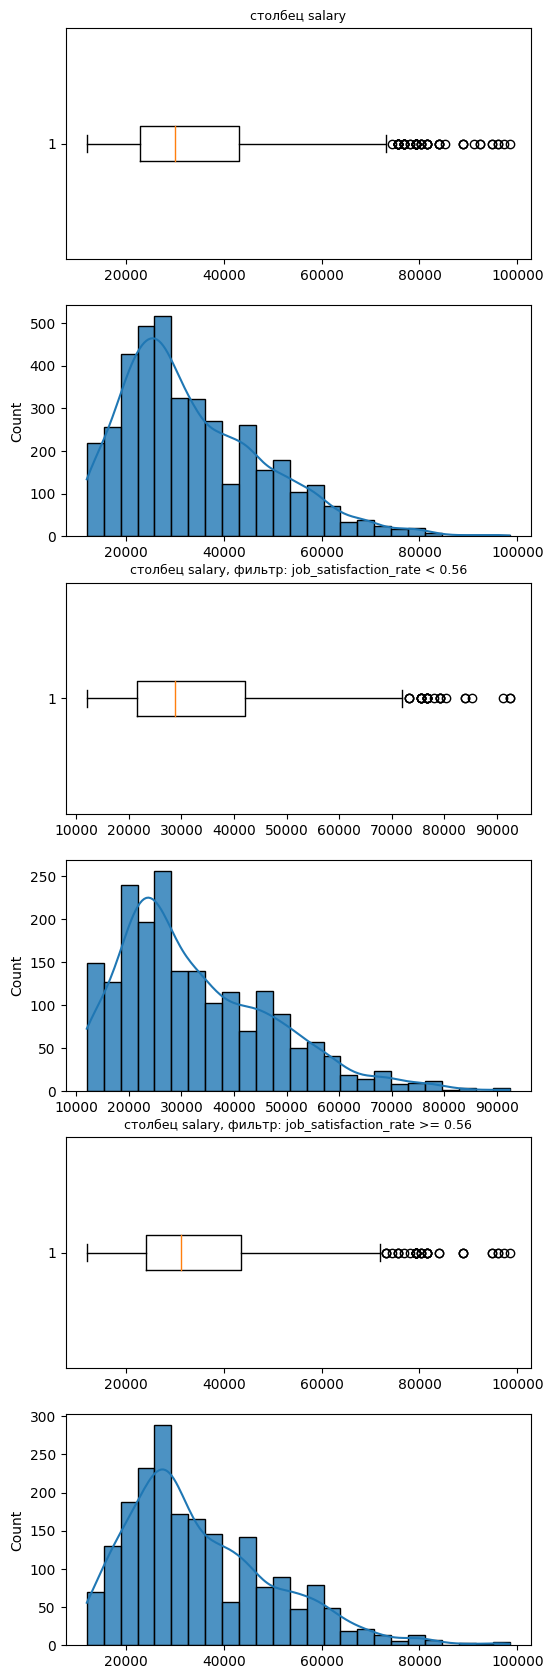

'********** Следующий признак: job_satisfaction_rate'

"фильтр = ''"

count    4000.000000
mean        0.533995
std         0.225327
min         0.030000
25%         0.360000
50%         0.560000
75%         0.710000
max         1.000000
Name: job_satisfaction_rate, dtype: float64

"фильтр = 'job_satisfaction_rate < 0.56'"

count    1980.000000
mean        0.339237
std         0.131060
min         0.030000
25%         0.240000
50%         0.350000
75%         0.440000
max         0.550000
Name: job_satisfaction_rate, dtype: float64

"фильтр = 'job_satisfaction_rate >= 0.56'"

count    2020.000000
mean        0.724896
std         0.100342
min         0.560000
25%         0.650000
50%         0.710000
75%         0.800000
max         1.000000
Name: job_satisfaction_rate, dtype: float64

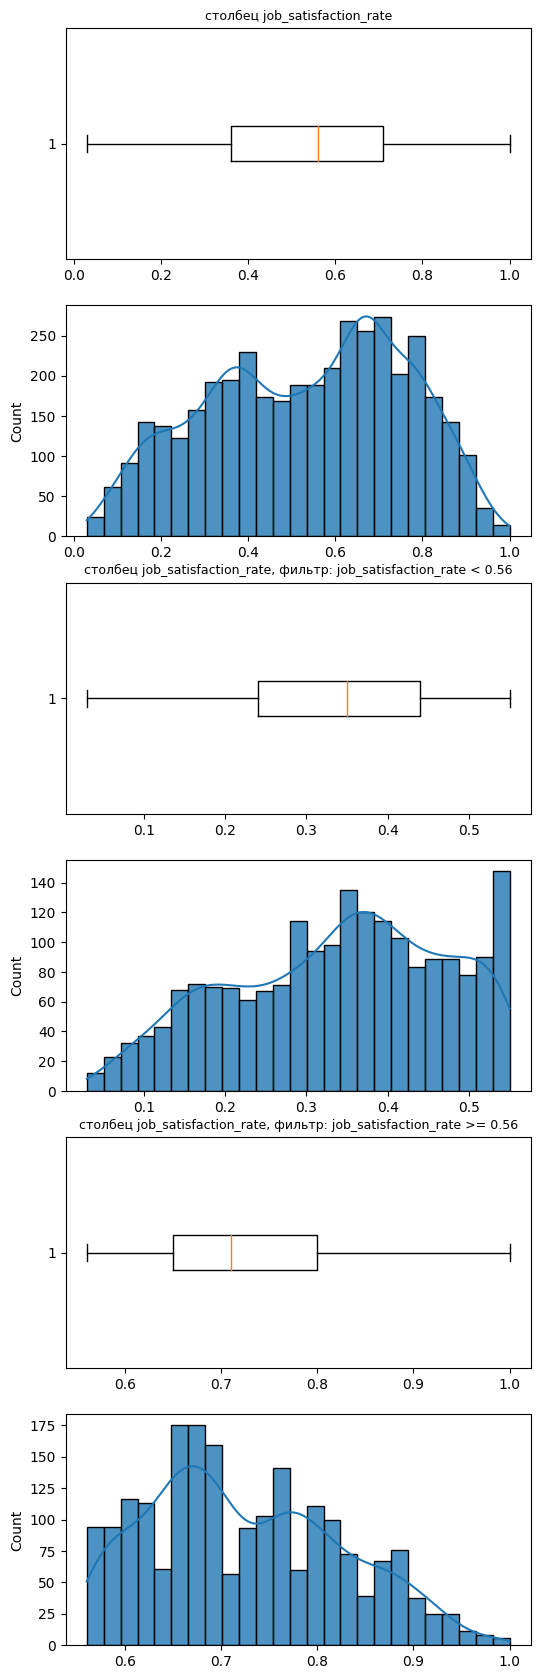

In [435]:
do_eda(train_df, ['', f'job_satisfaction_rate < {JOB_SATISFACTION_RATE_MEDIAN}', f'job_satisfaction_rate >= {JOB_SATISFACTION_RATE_MEDIAN}'])

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'employment_years')

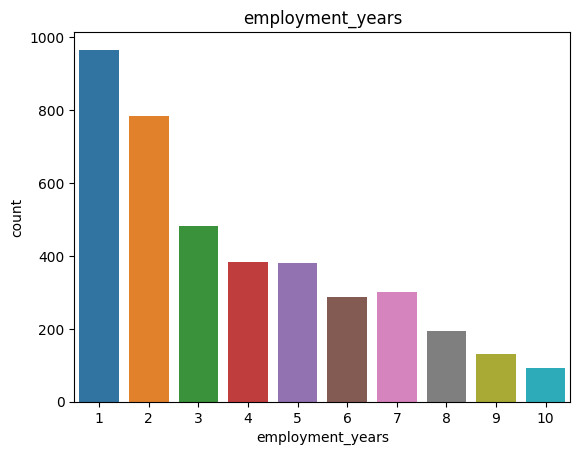

In [436]:
ax = sns.countplot(train_df['employment_years'], );
ax.set_title('employment_years')

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'supervisor_evaluation')

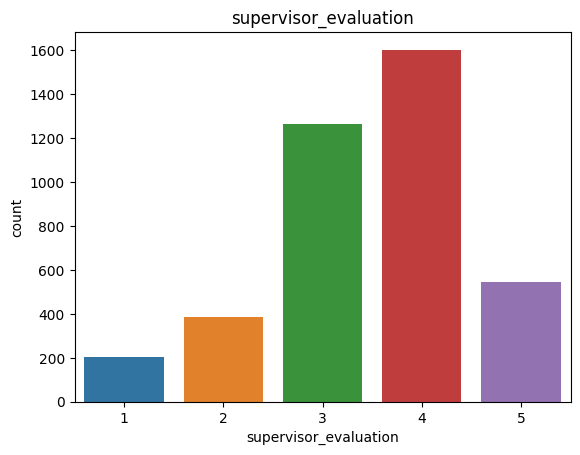

In [437]:
ax = sns.countplot(train_df['supervisor_evaluation'], );
ax.set_title('supervisor_evaluation')

Некоторые графики обратили на себя внимание - изучим их:
- больше всего отдел продаж (38%), за ним R&D (22%)
    - значит эта компания что-то производит и продаёт
    - по порогу удовлетворённости 0.5 значимой разницы не заметно (назовём их условно "довольные и "недовольные"). "Недовольных" больше в Technology, но лишь на 2% (21% против 23%).
- почти половина (47%) - джуны
    - Среди джунов чуть больше "недовольных" (49% против 46%)
    - среди миддлов чуть больше "довольных" (45% против 42%)
- сильно загружено лишь 18% сотрудников, 30% недозагружено
    - с одной стороны тут тихая гавань, и кому-то тут нравится
    - с другой стороны, это условия для скуки, особенно это опасно для активной  молодёжи (которой много), ждущей возможности себя проявить
    - по нагрузке профили "довольных" и "недовольных" довольно близки
- почти всем (97%) в прошлом году поднимали з.п.
    - хорошо для лояльности (но мы не знаем цифры)
    - жаль, что отсутствует фича сравнения вилок с рынком - это очень важное сравнение для оценки удержания, а у HR она обычно есть
    - "довольным" повышали зарплату в 4% случаев, "недовольным" - в 2%. Разница в 2 раза, но в любом случае это необычно малые проценты. Возможно, у компании не самые простые времена.
- 86% не нарушало договор
    - Среди "недовольных" нарушавших договор в ~5 раз больше (26% против 5%)
- медианная продолжительность работы в компании 3 года, RQ1-RQ3 от 2 до 6 лет - в целом вполне здоровая картина, заметной текучки не наблюдается
    - различий среди "довольных" и "недовольных" особых нет
- медианная оценка работы руководителем ~4
    - вполне здоровая картина
    - медианная оценка "довольных"=4, а "недовольных"=3
- распределние зарплат (но не сами значения, т. к. не знаем сравнения с рынком) также не вызывает вопросов
    - медианная зарплата "довольных"=31200, а "недовольных"=28800
- медианный уровень удовлетворённости 0.56, распределение сдвинуто вправо
    - характеризует атмосферу в компании как здоровую

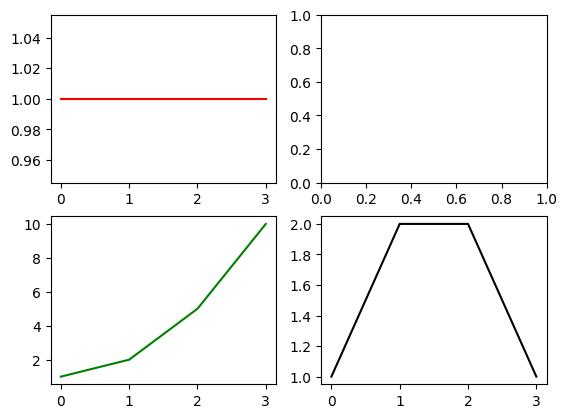

In [438]:
#код ревьюера


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Задаем subplots:
fig, ax = plt.subplots(nrows=2, ncols=2)
# fig - это "холст", ax графики на нем. Холст один, графиков может быть много. 

# Как мы размещаем графики и сколько определяем так:
# (nrows=2, ncols=2) - то есть у нас 4 графика, 2 на 2, а если (nrows=4, ncols=5) то у нас 20 графиков 4 строки на 5 столбцов
# ax[0, 0] - это график который находится в ячейке  1 (по строке) и 1 (по столбцу), ax[1, 0] - график в ячейке 2, 1 итд
# Рисуем:
# тут рисуем линию везде равную 1, рисуем красным в верхней левой части холста
ax[0, 0].plot([1,1,1,1,], 'red');
# тут линию растущую, зеленым
ax[1, 0].plot([1,2,5,10], 'green');

ax = ax.flatten()
# .flatten() -вытягивает в один ряд теперь  ax[0, 0] это ax[0], а ax[1, 1] это ax[3]. Так удобней 


ax[3].plot([1,2,2,1], 'black');


# Вообще то все о subplots! )))




C:\Users\Papa\AppData\Local\Temp\ipykernel_8268\1024620621.py:43: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


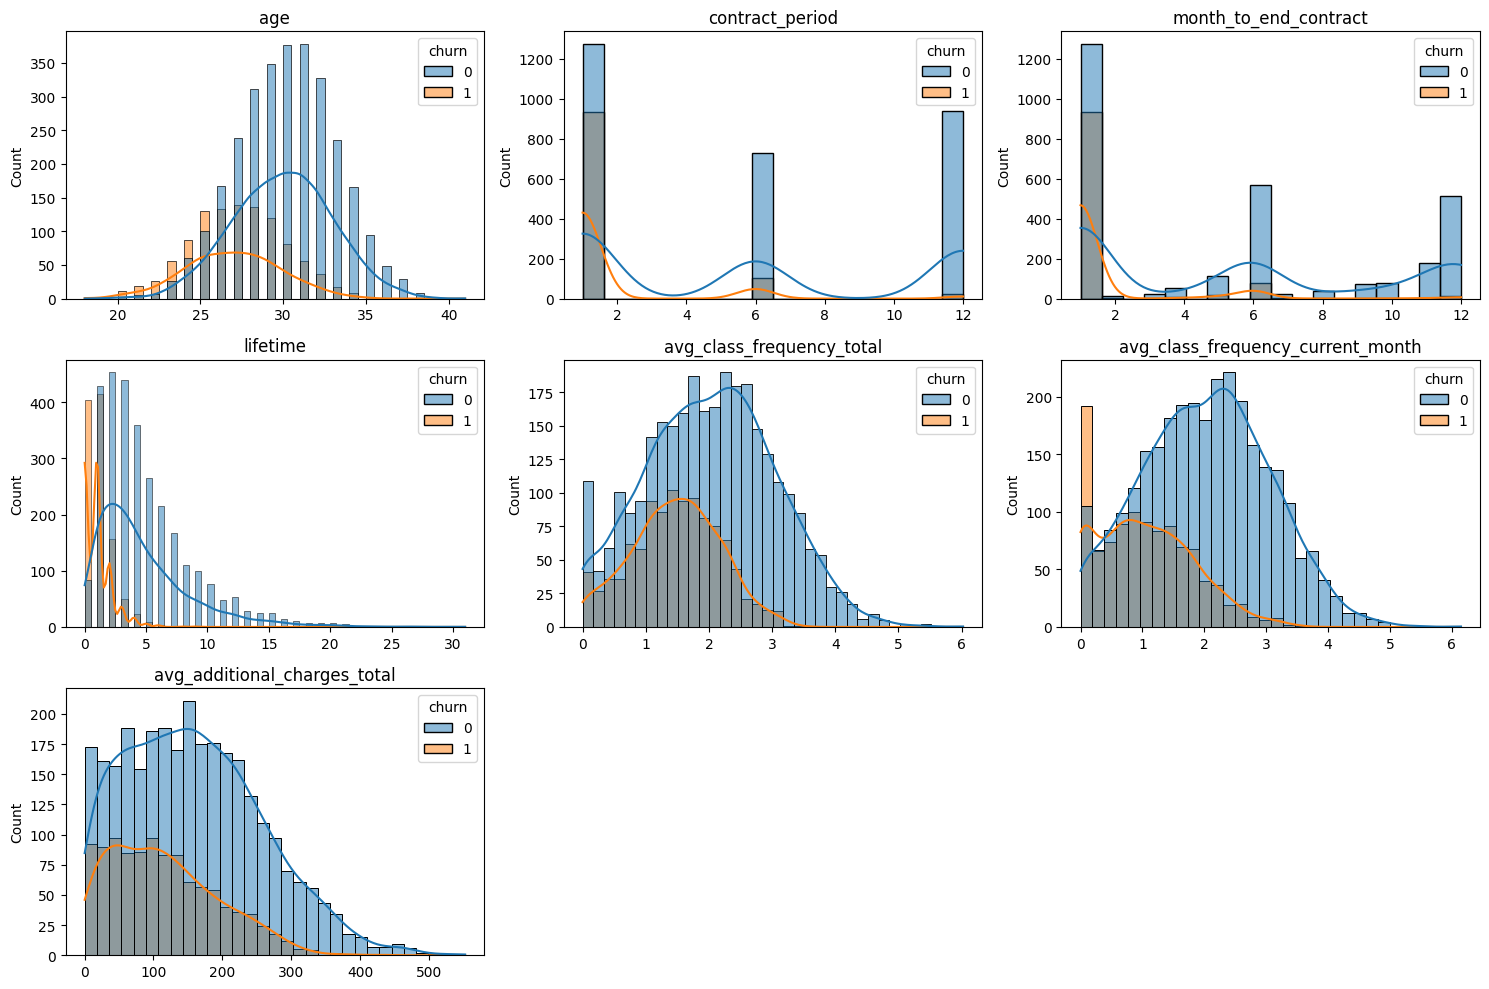

In [439]:
#код ревьюера


# Тут я использую датасет из другого проекта gym_churn.csv
df_rewier = pd.read_csv('https://code.s3.yandex.net/datasets/gym_churn.csv')
df_rewier.columns = [x.lower() for x in df_rewier.columns]


# А теперь мы можем в каждую ячейку поместить свой график либо вручную либо в цикле. Лучше конечно в цикле:
# делаем новых холст в котором графики будут в 3 столбца, а число строк - количество признаков деленное на 3

features = ['age', 'contract_period', 'month_to_end_contract', 'lifetime', 'avg_class_frequency_total', 'avg_class_frequency_current_month', 
'avg_additional_charges_total']


number_row = int(len(features)/3)
# добавим figsize=(15, 15) чтобы не было слишком мелкие графики
fig, ax = plt.subplots(nrows = number_row + 1, ncols=3, figsize=(15, 10))


# вытягиваем
ax = ax.flatten()

# задаем цикл
for i in range(len(features)):
    
# Обрати внимание Как с помощью hue='churn' делаем разбиение по нужному нам категориальному столбцу, в данном случае churn
# И смотри как мы задаём номер ячейки на холсте через ax=ax[i]
    sns.histplot(data = df_rewier, x = df_rewier[features[i]], hue='churn', ax=ax[i], kde = True,)

    ax[i].set_title(f'{features[i]}')
    ax[i].set_xlabel('')


# удалим 2 последних, ибо пустые  
fig.delaxes(ax[-1])
fig.delaxes(ax[-2])
            


# чтобы все надписи влезли    
fig.tight_layout()
fig.show()


# Лайфхак о subplots и hue окончен ))  Размещение графиков стало компактным. Можно строить техничнее, я показал как понятней

Оценим корреляцю между признаками ~~(закодируем важные текстовые фичи как ранговые)~~.

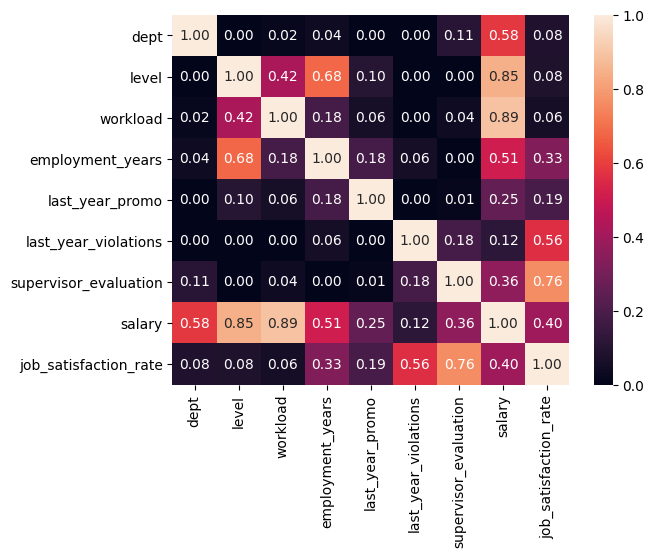

In [440]:
tmp = train_df.drop('id', axis=1)
sns.heatmap(tmp.phik_matrix(interval_cols=['job_satisfaction_rate'], bins={'job_satisfaction_rate':10}), annot=True, fmt='.2f');

Как говорилось, в лекциях:
        - *Как правило, о мультиколлинеарности говорят при значении коэффициента корреляции от 0.9 до 0.95 по модулю. В такой ситуации лишние коррелирующие признаки нужно удалять из обучающей выборки.*

Мультиколлинеарности не наблюдается.

Наиболее коррелируют:
- 0.89: зарплата <-> нагрузка
- 0.85: зарплата <-> уровень должности
- 0.76: уровень удовлетворённости сотрудника <-> оценка руководителем
- 0.68: длительность работы <-> уровень должности

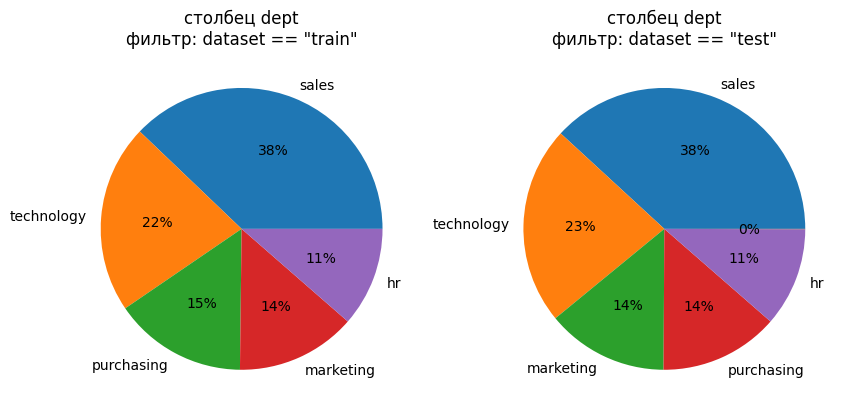

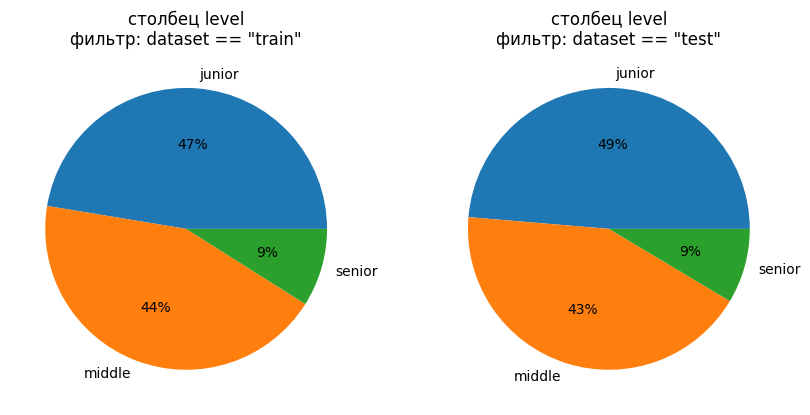

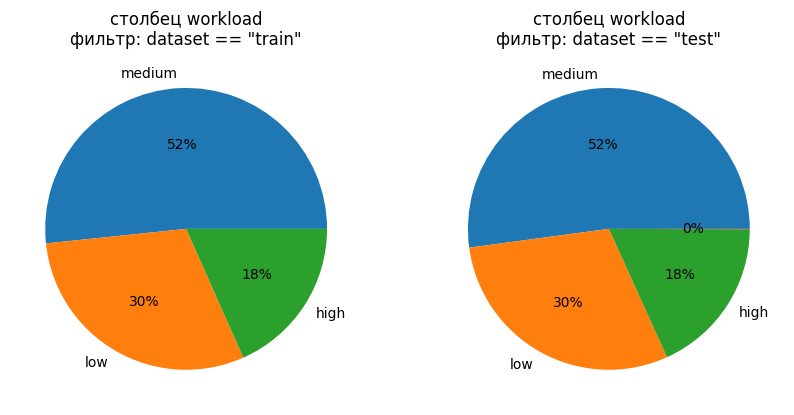

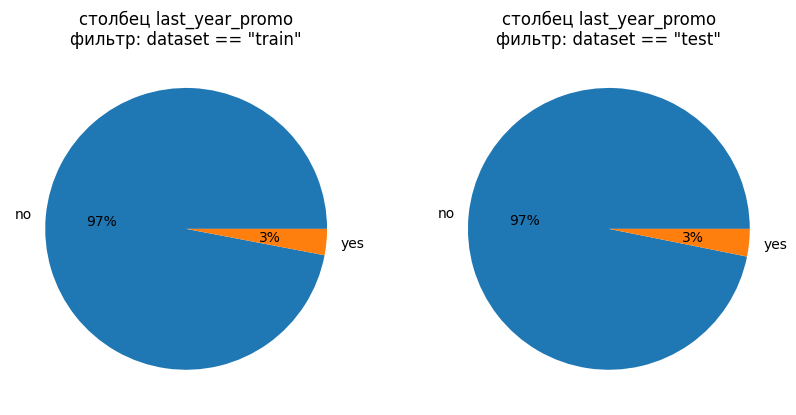

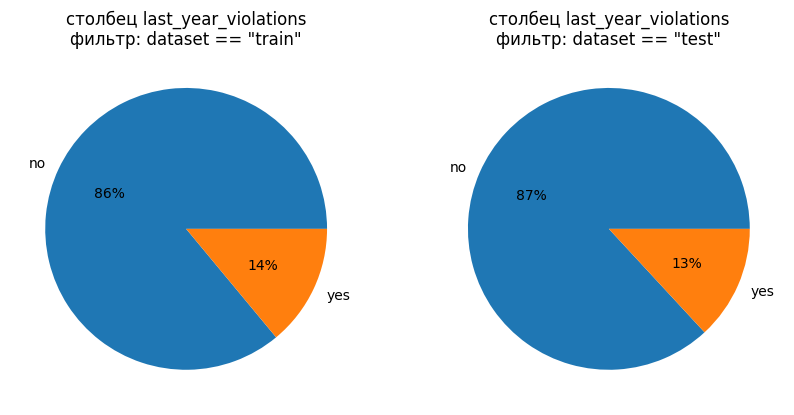

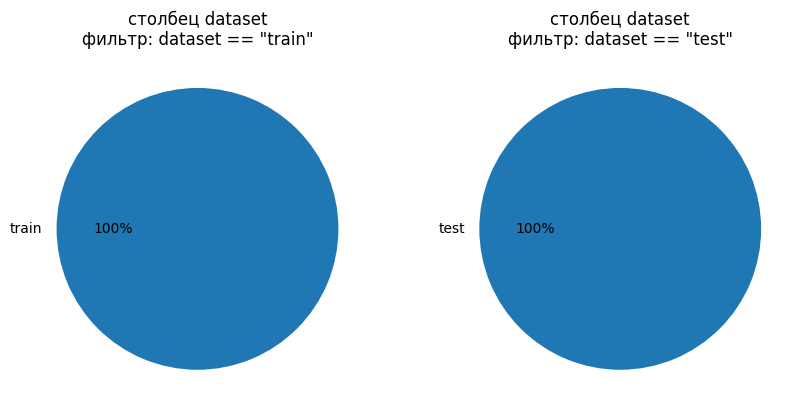

'********** Следующий признак: employment_years'

'фильтр = \'dataset == "train"\''

count    4000.000000
mean        3.718500
std         2.542513
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64

'фильтр = \'dataset == "test"\''

count    1997.000000
mean        3.670506
std         2.537020
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64

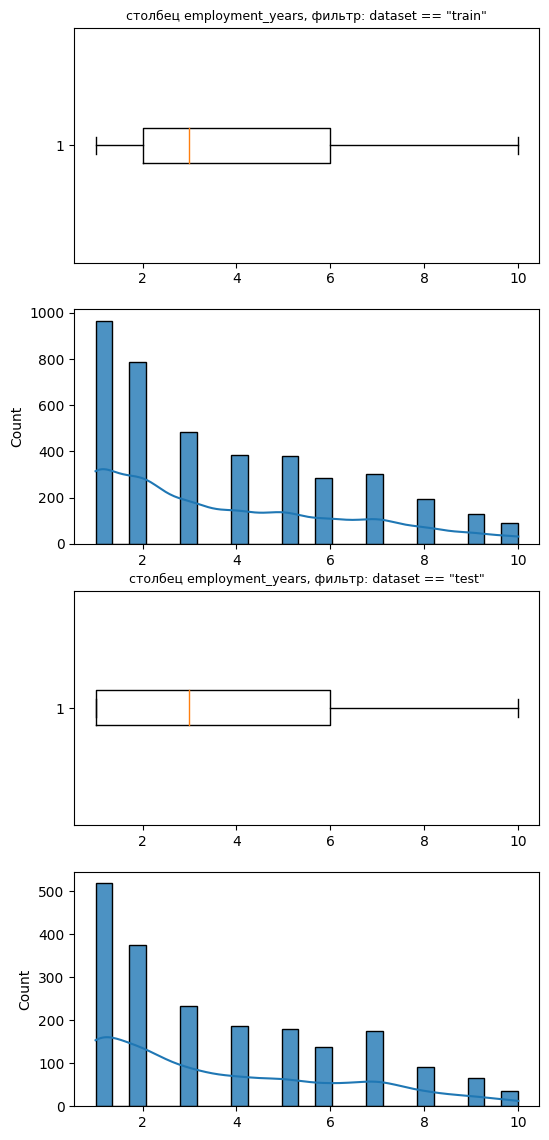

'********** Следующий признак: supervisor_evaluation'

'фильтр = \'dataset == "train"\''

count    4000.000000
mean        3.476500
std         1.008812
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

'фильтр = \'dataset == "test"\''

count    1997.000000
mean        3.527792
std         0.995910
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

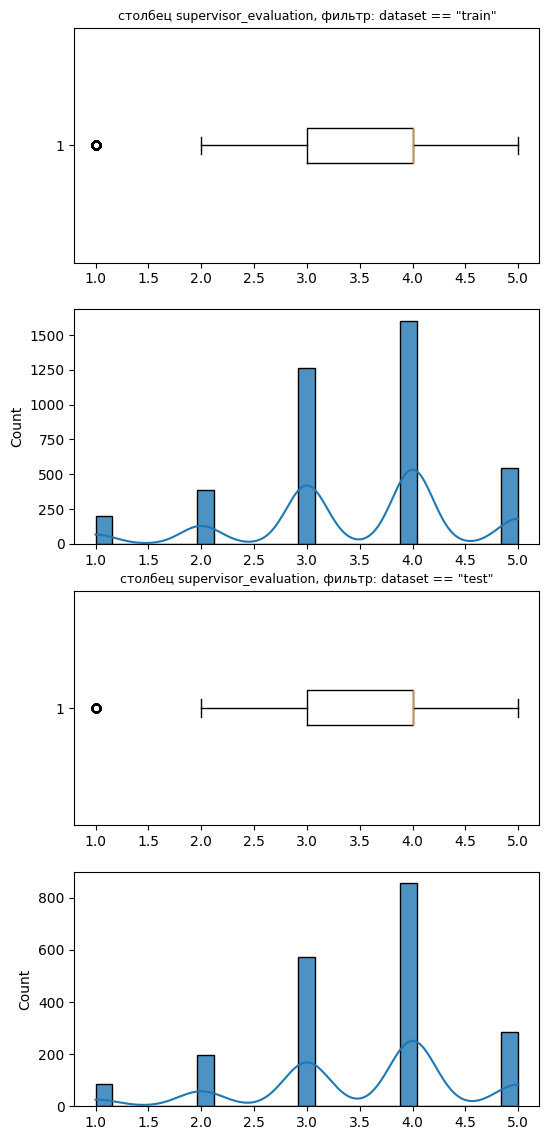

'********** Следующий признак: salary'

'фильтр = \'dataset == "train"\''

count     4000.000000
mean     33926.700000
std      14900.703838
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      98400.000000
Name: salary, dtype: float64

'фильтр = \'dataset == "test"\''

count     1997.000000
mean     34087.330996
std      15398.583620
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64

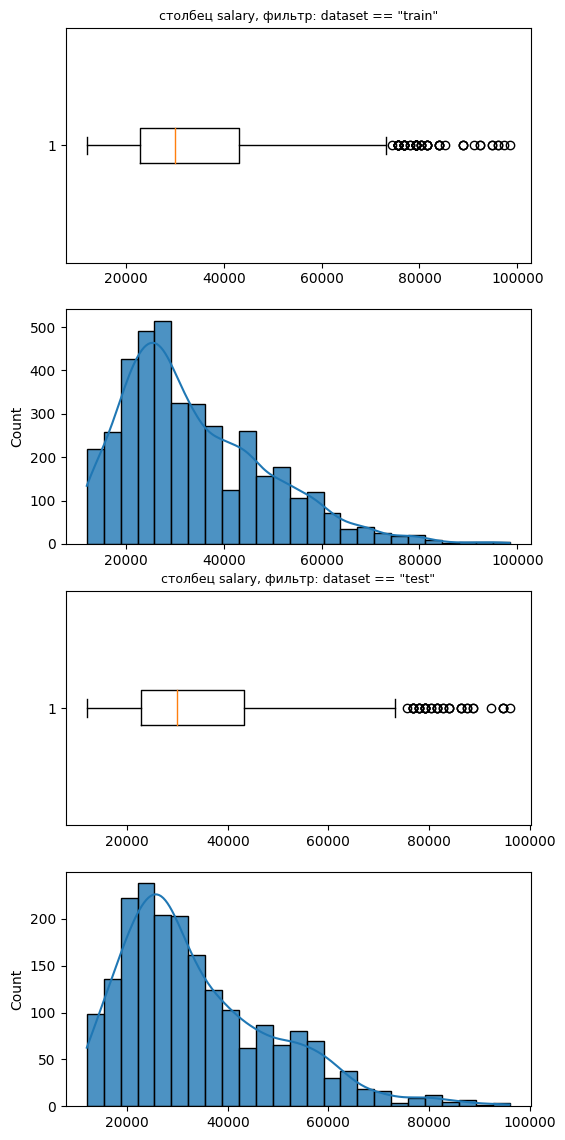

'********** Следующий признак: job_satisfaction_rate'

'фильтр = \'dataset == "train"\''

count    4000.000000
mean        0.533995
std         0.225327
min         0.030000
25%         0.360000
50%         0.560000
75%         0.710000
max         1.000000
Name: job_satisfaction_rate, dtype: float64

'фильтр = \'dataset == "test"\''

count    1997.000000
mean        0.549154
std         0.219898
min         0.030000
25%         0.380000
50%         0.580000
75%         0.720000
max         1.000000
Name: job_satisfaction_rate, dtype: float64

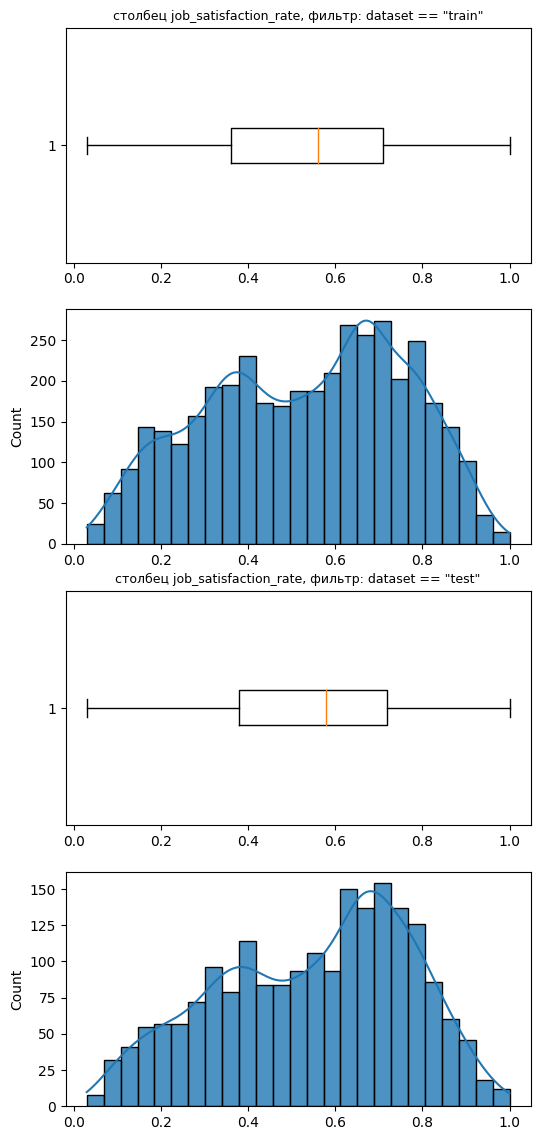

In [441]:
tmp_train = train_df.copy().drop(['id'], axis=1)
tmp_train['dataset']='train'
tmp_test = test_df.copy().drop(['id'], axis=1)
tmp_test['dataset']='test'

tmp = pd.concat([tmp_test, tmp_train], axis=0)

do_eda(tmp, ['dataset == "train"', 'dataset == "test"'])

Выявленная разница между распределениями полей тренировочного и тестовым датастов:
- малая разница (1-2%)
    - dept
    - level
    - last_year_violation
- в тестовой выборке больше новичков (Q1 = 1 в тестовой и Q1 = 2 в тренировочной) - хотя, это дискретные данные, как выше писали

Существенной разницы между распределениями полей тренировочного и тестовым датастов - не выявлено.

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 4. Подготовка данных
Подготовку признаков выполните в пайплайне, дополнив пайплайн шагом предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.

Целевой признак - уровень удовлетворённости, float, значит мы решаем задачу регрессии.

In [442]:
# ord_columns - уже задан выше

ohe_columns = ['dept']
ord_columns = [
    'level',
    'workload',
    'last_year_promo',
    'last_year_violations'
]
num_columns = ['employment_years',
               'supervisor_evaluation',
               'salary'
]

ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
    )

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[['junior', 'middle', 'senior'],
                            ['low', 'medium', 'high'],
                            ['no', 'yes'],
                            ['no', 'yes']],     
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns),
    ], 
    remainder='passthrough'
) 

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 5. Обучение моделей
Обучите как минимум две модели. Возьмите одну линейную модель, а в качестве второй — дерево решений. Подберите гиперпараметры как минимум для одной модели с помощью одного из известных вам инструментов.
Выберите лучшую модель и проверьте её качество. Выбор делайте на основе новой метрики — SMAPE (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»). 
Метрика SMAPE вычисляется так: ...

Напишите функцию, которая принимает на вход массивы NumPy или объекты Series в pandas и возвращает значение метрики SMAPE. Используйте эту метрику при подборе гиперпараметров и оценке качества моделей. 
Критерий успеха: SMAPE ≤ 15 на тестовой выборке.
В решении сохраните работу со всеми моделями, которые вы пробовали. Сделайте выводы.

In [443]:
def smape (y_true, y_pred):
    if len(y_true) != len(y_pred):
        raise Exception("error with length in smape")
    a = np.abs(y_pred - y_true) / ((np.abs(y_pred) + np.abs(y_true)) / 2)
    return 100*np.mean(a)

In [444]:
train_df

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20
...,...,...,...,...,...,...,...,...,...,...
3995,457950,technology,junior,high,2,no,no,3,46800,0.45
3996,957499,sales,junior,medium,2,no,no,4,21600,0.68
3997,533318,sales,middle,low,7,no,no,5,24000,0.76
3998,706868,sales,junior,medium,2,no,no,3,24000,0.48


In [445]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])


param_grid = [
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(1, 10),
        'models__min_samples_split': range(2, 7),
        'models__min_samples_leaf': range(1, 5),
        'models__max_features': range(1, 10),
        'preprocessor__num': [StandardScaler(), 'passthrough']   
    },
    {
        'models': [SVR()],
        'models__kernel': ['poly', 'rbf'],
        'models__degree': range(2, 7),
        'models__epsilon': [0.1, 0.3, 0.5],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
    {
        'models': [RandomForestRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(30, 200),
        'models__n_estimators': range(30, 200),
##v3        'models__min_samples_split': range(2, 50),
##v3        'models__min_samples_leaf': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    }
]

In [446]:
smape_scorer = make_scorer(smape, greater_is_better=False)

In [447]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid,
    cv=5,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_iter=100,
    verbose = 3,
    n_jobs=-1
)

In [448]:
X_train = train_df.drop(['job_satisfaction_rate', 'id'], axis=1)
y_train = train_df['job_satisfaction_rate']

In [449]:
%%time
randomized_search.fit(X_train, y_train)
display('Лучшая модель и её параметры:', randomized_search.best_estimator_, )
display ('SMAPE лучшей модели на кроссвалидации:', randomized_search.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


'Лучшая модель и её параметры:'

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequ...
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload',
                                                   'last_year_promo',
                                                   'last_year_violations']),
                                                 ('num', MinMaxScaler(),
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary'])])),
                ('models',
                 RandomForestRegressor(max_depth=163, n_estimators=196,
                                       random_state=42))])

'SMAPE лучшей модели на кроссвалидации:'

-13.199769168528576

CPU times: total: 6.88 s
Wall time: 2min


Рассчитаем показатель на отложенной тестовой выборке.

In [450]:
display ('SMAPE лучшей модели на тренировочной выборке:', randomized_search.cv_results_)

'SMAPE лучшей модели на тренировочной выборке:'

{'mean_fit_time': array([2.79674482, 0.05440187, 2.04827929, 1.9000402 , 1.14638362,
        1.85204277, 3.24843817, 2.13290954, 2.26927519, 0.74015923,
        1.61622024, 2.16969461, 3.33524604, 0.7380487 , 0.0501699 ,
        0.66831846, 1.47326307, 1.27505703, 1.1356998 , 1.54840493,
        2.81238317, 1.13336778, 0.86559072, 0.8773396 , 2.52789569,
        0.93301744, 1.71896839, 0.58789458, 0.05007892, 2.47370987,
        2.37580686, 2.80506949, 0.80374999, 0.91587195, 1.9167891 ,
        2.81754327, 2.35068727, 1.06836767, 1.34829211, 1.65478363,
        1.56970677, 2.38469477, 0.73470144, 2.13021164, 0.80266328,
        2.9207037 , 1.1279357 , 0.61979237, 2.77505298, 2.45551744,
        3.38615327, 0.90080018, 2.30747852, 3.11203508, 1.5669878 ,
        2.09629622, 1.09388123, 1.44917684, 0.6859509 , 1.89119425,
        1.40743241, 2.59735532, 2.60694613, 2.93861804, 3.30219903,
        2.39190078, 3.11173162, 2.30571146, 2.66884904, 2.21350827,
        2.59391623, 1.98961768,

In [451]:
X_test = test_df.drop(['id', 'job_satisfaction_rate'], axis=1)
y_test = test_df['job_satisfaction_rate'].values
y_pred = randomized_search.best_estimator_.predict(X_test)
display(f"SMAPE на тестовой выборке: {smape(y_test, y_pred)}")

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


'SMAPE на тестовой выборке: 12.396457394129124'

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 6. Оформление выводов
Сделайте промежуточные выводы о том, какая модель справилась лучше и почему.

Лучший показатель на кроссвалидации SMAPE (0.89) показала модель:
RandomForestRegressor(max_depth=149, min_samples_leaf=4, min_samples_split=12, n_estimators=48)

Почему справилась лучше именно random forest - затрудняюсь ответить. Но лучшая она - по итогам подбора гиперпараметров с помощью RandomizedSearchCV.

Сохраним данные для будущего использования:

In [452]:
train_df_1  = train_df.copy()
test_df_1   = test_df.copy()
X_train_1   = X_train.copy()
y_train_1   = y_train.copy()
X_test_1    = X_test.copy()
y_test_1    = y_test.copy()
y_pred_1    = y_test.copy()
randomized_search_1 = randomized_search

In [453]:
 # код ревьюера
 # Создаем DataFrame
df_my = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6]
})

# Давай его посмотрим
print('Вот так выглядит df_my изначально')
display(df_my)

# А теперь давай создадим "копию" DataFrame без использования .copy()
df_fake_copy = df_my


# А теперь вносим изменения в "копию"
df_fake_copy.loc[0, 'A'] = 100
print('Вот так выглядит df_fake_copy  после внесения изменений')
display(df_fake_copy)

# А теперь вопрос на засыпку, что произойдёт с df_my?

 
 
 # Смотрим
display(df_my)
# И оказывается что он принял все изменения df_fake_copy


# Но в чём тогда смысл df_copy = df_my, если изменения в одном, немедленно приведёт к изменениям в другом? 
# 
# Чтобы сделать настоящую копию:

df_real_copy = df_my.copy()

# И теперь если мы внесём изменения в df_real_copy, это не приведёт к изменениям в df_my, а если мы изменим df_my, 
# df_real_copyэто не приведёт к изменениям 

#  обрати на это внимание

# Почему так происходит .copy()? Python, объекты, такие как DataFrame, являются ссылочными типами данных. 
# Это означает, что переменные, которые хранят эти объекты, фактически хранят ссылки на место в памяти, 
# где находится объект. Давай посмотрим id df_my и id df_fake_copy
df_my_id = id(df_my)
df_fake_copy_id = id(df_fake_copy)

print(f"Смотрим сектора хранения информации df_my: {df_my_id} и df_fake_copy_id: {df_fake_copy_id}")

# И видим что они идентичные! То есть наши это фреймы по-прежнему ссылаются на один и тот же сектор
# Вот поэтому изменения в одном приводят к изменению в другом

Вот так выглядит df_my изначально


,A,B
0,1,4
1,2,5
2,3,6


Вот так выглядит df_fake_copy  после внесения изменений


,A,B
0,100,4
1,2,5
2,3,6


,A,B
0,100,4
1,2,5
2,3,6


Смотрим сектора хранения информации df_my: 1832585704112 и df_fake_copy_id: 1832585704112


Дальше мы будем копипастить старый код. Чтобы в новые рассчёты не закрались старые переменные - удалим их явно (для уверенности, что оперируем далее вновь созданными экземплярами - пусть Python ругается на использование непересозданных переменных)

In [454]:
del train_df
del test_df
del X_train
del y_train
del X_test
del y_test
del y_pred
del randomized_search

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

# Задача 2: предсказание увольнения сотрудника из компании

Для этой задачи вы можете использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.

## Шаг 1. Загрузка данных

Загрузите данные из файлов:
Тренировочная выборка:
train_quit.csv
Входные признаки тестовой выборки те же, что и в прошлой задаче:
test_features.csv
Целевой признак тестовой выборки:
test_target_quit.csv


In [455]:
train_df = def_load_csv ('train_quit.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


None

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [456]:
test_X_df = def_load_csv ('test_features.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [457]:
test_y_df = def_load_csv ('test_target_quit.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


None

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 2. Предобработка данных

Изучите данные и при необходимости выполните предобработку. Если есть пропуски, заполните их в пайплайне.

- В типах данных проблем не обнаружено.
- Имена полей соответствуют camel-нотации.
- 4000 - приемлемый размер обучающей выборки

Изучим пропуски

In [458]:
display(train_df.isna().sum())

id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
dtype: int64

In [459]:
display(train_df.isna().sum())

id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
dtype: int64

In [460]:
display(train_df.isna().sum())

id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
dtype: int64

Пропусков не обнаружено.

Объединим таблицы с тестовыми фичами и таргетом.

In [461]:
test_df = test_X_df.merge(test_y_df, on = 'id', how='left') \
    .reset_index(drop=True)

In [462]:
test_df = test_df.dropna().reset_index(drop=True)
display(test_df)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,no
1,686555,hr,junior,medium,1,no,no,4,30000,no
2,467458,sales,middle,low,5,no,no,4,19200,no
3,418655,sales,middle,low,6,no,no,4,19200,no
4,789145,hr,middle,medium,5,no,no,5,40800,no
...,...,...,...,...,...,...,...,...,...,...
1992,393147,marketing,junior,low,3,no,no,3,20400,yes
1993,109582,technology,middle,low,3,no,no,2,21600,yes
1994,305653,technology,junior,low,1,no,no,3,14400,yes
1995,160233,technology,middle,low,8,no,no,1,32400,no


Изучим явные дубликаты

In [463]:
display(train_df.duplicated().sum())

0

In [464]:
display(test_df.duplicated().sum())

0

Явных дубликатов не найдено.

Изучим неявные дубликаты в датафрейме

In [465]:
def test_implicit_dublicates (df):
    for column in df:
        if df[column].dtype == 'O':
            display(f"столбец {column}")
            display(df[column].value_counts())

test_implicit_dublicates (train_df)

'столбец dept'

sales         1438
technology     928
purchasing     588
marketing      582
hr             464
Name: dept, dtype: int64

'столбец level'

junior    1949
middle    1694
sinior     357
Name: level, dtype: int64

'столбец workload'

...

no     3887
yes     113
Name: last_year_promo, dtype: int64

'столбец last_year_violations'

no     3455
yes     545
Name: last_year_violations, dtype: int64

'столбец quit'

no     2872
yes    1128
Name: quit, dtype: int64

Исправим опечатку, в остальном всё хорошо.

In [466]:
train_df['level'] = train_df['level'].replace('sinior', 'senior')
test_df['level'] = test_df['level'].replace('sinior', 'senior')

In [467]:
test_implicit_dublicates (test_df)

'столбец dept'

sales         762
technology    455
marketing     279
purchasing    273
hr            227
                1
Name: dept, dtype: int64

'столбец level'

junior    972
middle    854
senior    171
Name: level, dtype: int64

'столбец workload'

...

no     1934
yes      63
Name: last_year_promo, dtype: int64

'столбец last_year_violations'

no     1735
yes     262
Name: last_year_violations, dtype: int64

'столбец quit'

no     1435
yes     562
Name: quit, dtype: int64

Закодируем целевой признак (можно через энкодер, но проще руками в данном случае):

In [469]:
label_encoder = LabelEncoder()
label_encoder.fit(train_df ['quit'])

train_df ['quit']= label_encoder.transform(train_df ['quit'])
test_df ['quit'] = label_encoder.transform(test_df ['quit']) 

display(label_encoder.classes_)

array(['no', 'yes'], dtype=object)

yes получил класс 1, как я и хотел

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 3. Исследовательский анализ данных
### 3.1. Проведите исследовательский анализ данных.

Изучим категориальные значения

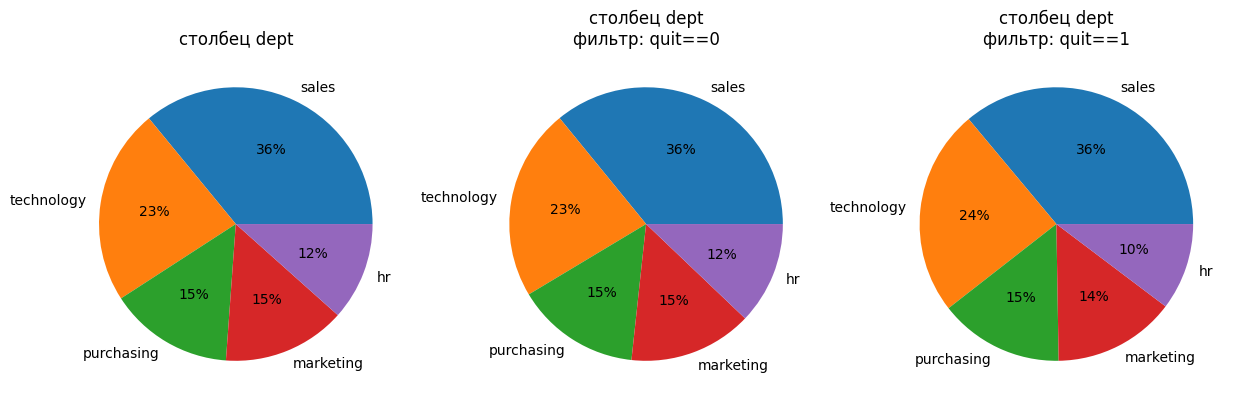

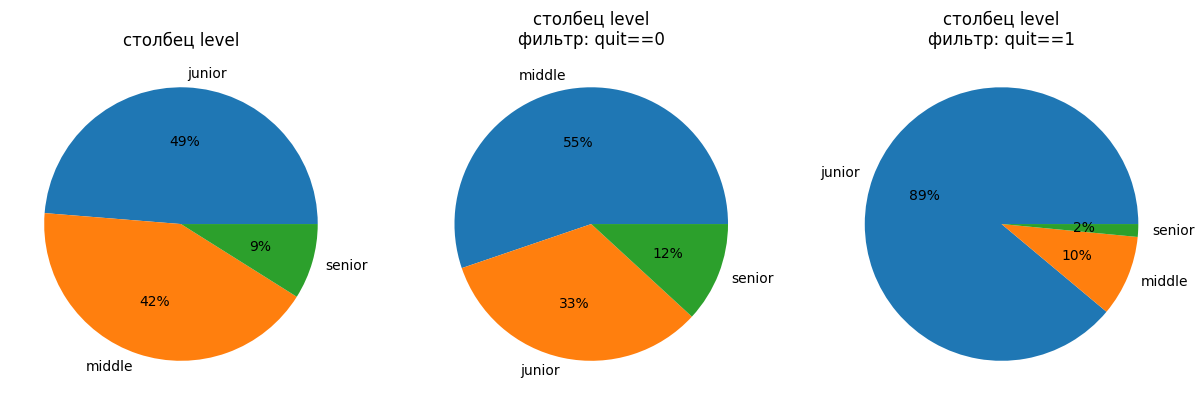

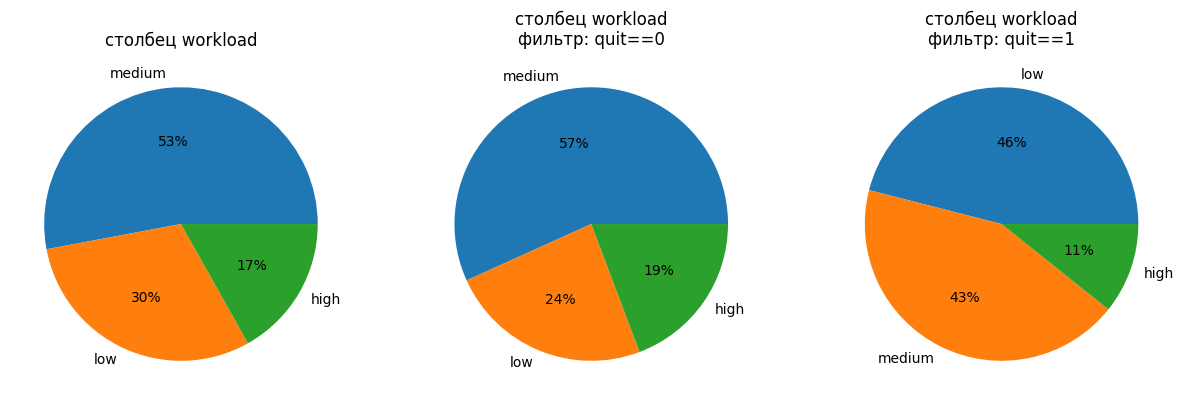

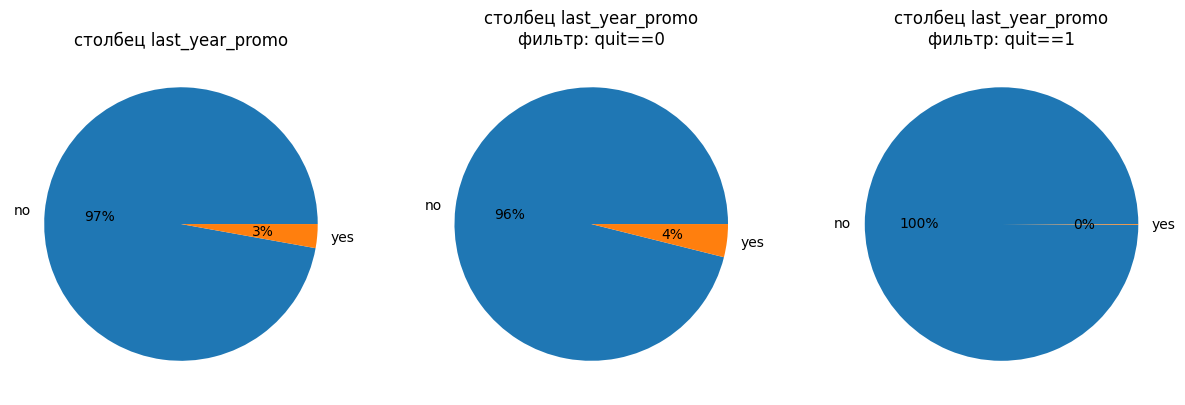

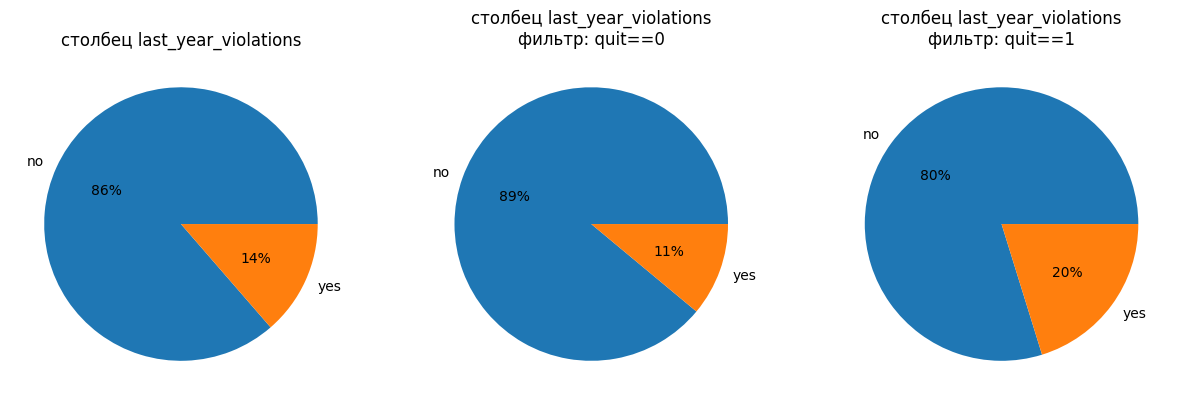

'********** Следующий признак: employment_years'

"фильтр = ''"

count    4000.000000
mean        3.701500
std         2.541852
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64

"фильтр = 'quit==0'"

count    2872.000000
mean        4.430710
std         2.544635
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64

"фильтр = 'quit==1'"

count    1128.000000
mean        1.844858
std         1.274920
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: employment_years, dtype: float64

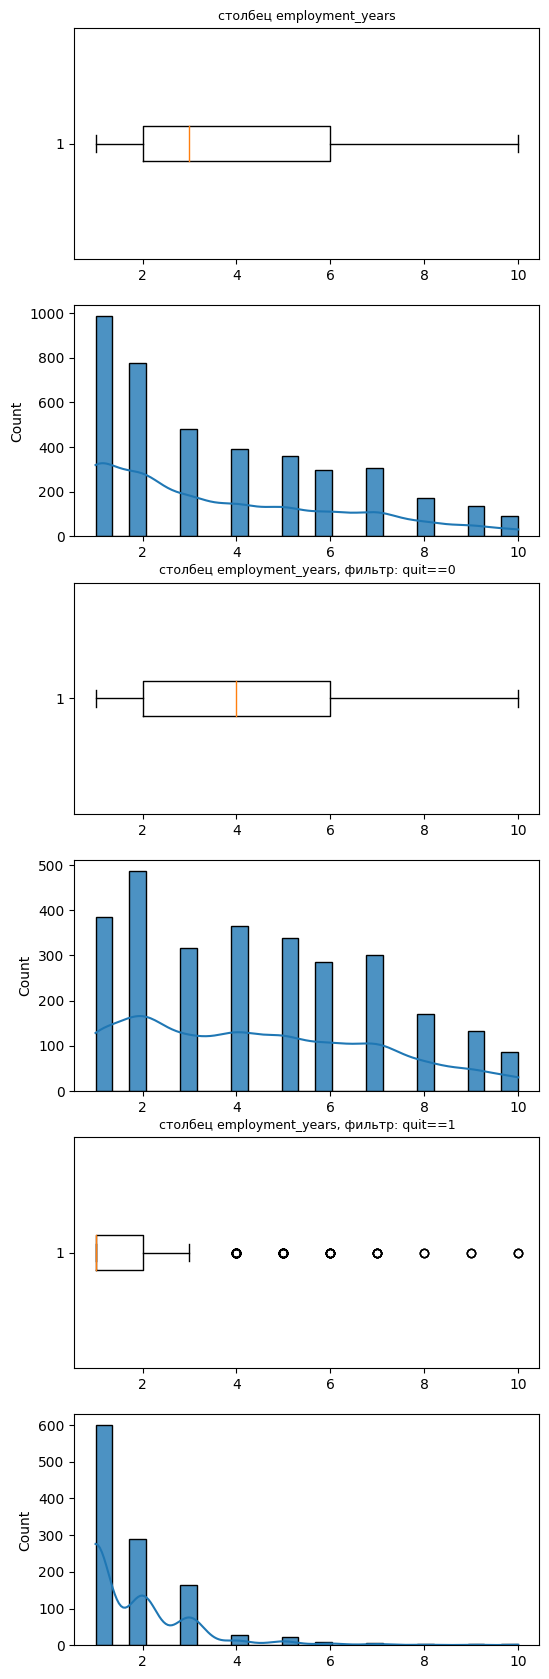

'********** Следующий признак: supervisor_evaluation'

"фильтр = ''"

count    4000.000000
mean        3.474750
std         1.004049
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

"фильтр = 'quit==0'"

count    2872.000000
mean        3.643106
std         0.965295
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

"фильтр = 'quit==1'"

count    1128.000000
mean        3.046099
std         0.973291
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

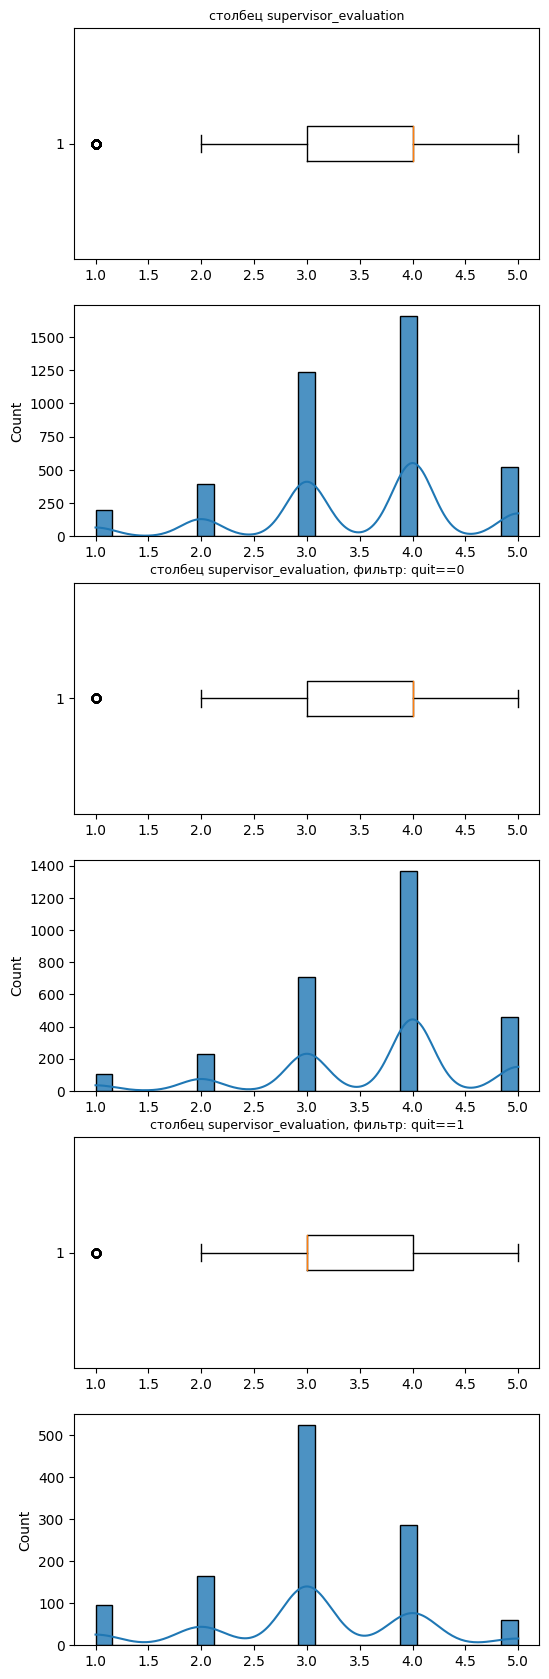

'********** Следующий признак: salary'

"фильтр = ''"

count     4000.000000
mean     33805.800000
std      15152.415163
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64

"фильтр = 'quit==0'"

count     2872.000000
mean     37702.228412
std      15218.977339
min      12000.000000
25%      25200.000000
50%      34800.000000
75%      46800.000000
max      96000.000000
Name: salary, dtype: float64

"фильтр = 'quit==1'"

count     1128.000000
mean     23885.106383
std       9351.599505
min      12000.000000
25%      16800.000000
50%      22800.000000
75%      27600.000000
max      79200.000000
Name: salary, dtype: float64

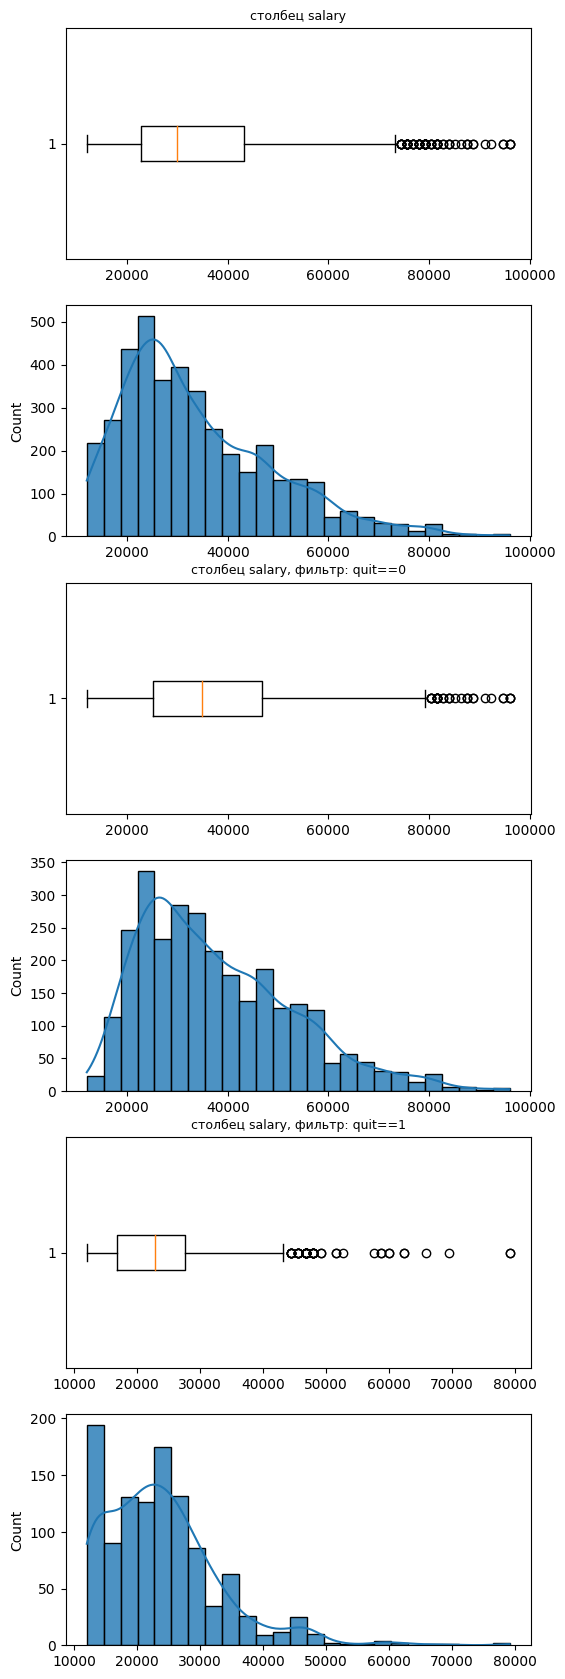

In [470]:
do_eda(train_df, ['', 'quit==0', 'quit==1'])

Некоторые графики обратили на себя внимание - изучим их:

- больше всего отдел продаж (36%), за ним R&D (23%)
    - вероятно, это та же комания
    - эта компания что-то производит и продаёт
- почти половина (49%) - джуны
    - среди уволившихся:
        - джунов значительно больше (89% против 55%)
        - миддлов значительно меньше (10% против 33%)
        - сеньоров значительно меньше (2% против 12%)
- сильно загружено лишь 17% сотрудников, 30% недозагружено
    - с одной стороны тут тихая гавань, и кому-то тут нравится
    - с другой стороны, это условия для скуки, особенно это опасно для активной  молодёжи (которой много), ждущей возможности себя проявить
    - сильно-загруженных среди уволившихся значительно меньше (11% против 19%)
    - средне-загруженных среди уволившихся значительно больше (42% против 24%)
- почти всем (97%) в прошлом году поднимали з.п.
    - хорошо для лояльности (но мы не знаем цифры)
    - жаль, что отсутствует фича сравнения вилок с рынком - это очень важное сравнение для оценки удержания, а у HR она обычно есть
    - среди уволившихся практически никому (~0%) не поднимали зарплату 
- 86% не нарушало договор
    - но это не особо сильная фича, это нормально
    - среди уволившихся вдвое больше нарушали контракт (20% против 11%)
- медианная продолжительность работы в компании 3 года, RQ1-RQ3 от 2 до 6 лет - в целом вполне здоровая картина, заметной текучки не наблюдается
    - уволившиеся в медианном отработали 1 год, а работающие - 4 года
- медианная оценка 4
    - вполне здоровая картина
    - однако медианная оценка уволившихся = 3, а работающих = 4
- распределние зарплат (но не сами значения, т. к. не знаем сравнения с рынком) также не вызывает вопросов
    - медианная зарплата уволившихся = 22800, а работающих = 34800 (что в 1.5 раза больше)
- Компанию готовы покинуть 28% сотрудников.
    - это очень плохой показатель
- Джуны чаще уходят из sales и technologies, чем из других отделов.

Text(0.5, 1.0, 'уволившиеся люди по отделам')

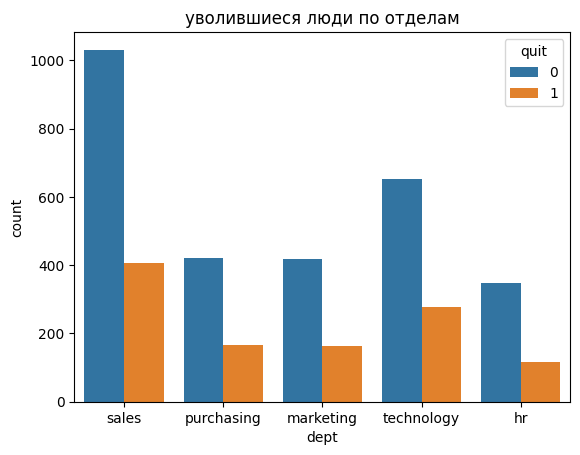

In [471]:
ax = sns.countplot(data=train_df, x = 'dept', hue='quit');
ax.set_title('уволившиеся люди по отделам')

Text(0.5, 1.0, 'уволившиеся джуны по отделам')

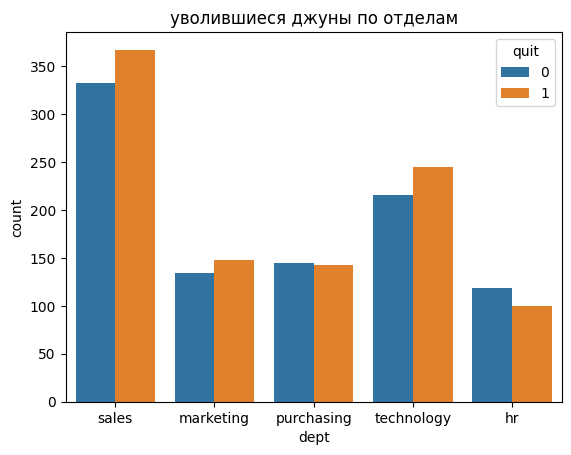

In [472]:
ax = sns.countplot(data=train_df.query('level=="junior"'), x = 'dept', hue='quit');
ax.set_title('уволившиеся джуны по отделам')

Джуны чаще уходят из sales и technologies, чем из других отделов. Добавил в выводы.

Оценим корреляцю между признаками ~~(закодируем важные текстовые фичи как ранговые)~~.

In [473]:
train_df

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,0
1,814010,sales,junior,medium,2,no,no,4,27600,0
2,155091,purchasing,middle,medium,5,no,no,1,37200,0
3,257132,sales,junior,medium,2,no,yes,3,24000,1
4,910140,marketing,junior,medium,2,no,no,5,25200,0
...,...,...,...,...,...,...,...,...,...,...
3995,588809,sales,junior,medium,4,no,no,3,26400,0
3996,672059,sales,middle,high,9,no,no,4,52800,0
3997,536432,purchasing,junior,low,2,no,yes,4,12000,1
3998,692133,purchasing,middle,medium,2,no,no,4,33600,0


interval columns not set, guessing: ['employment_years', 'supervisor_evaluation', 'salary', 'quit']


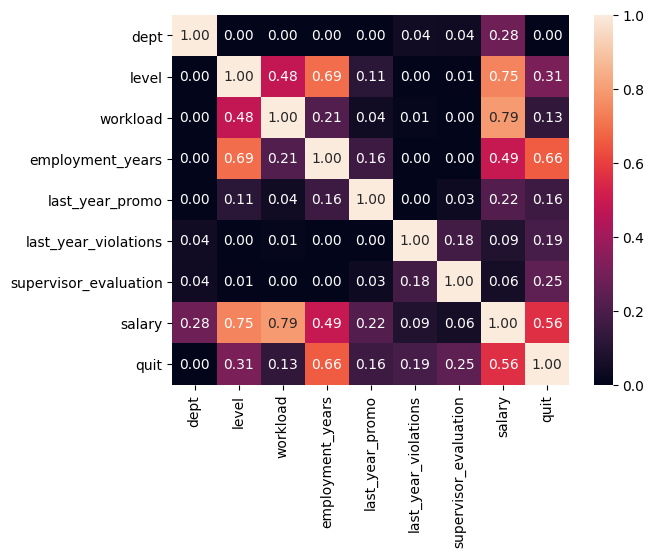

In [474]:
tmp = train_df.copy().drop('id', axis=1)
sns.heatmap(tmp.phik_matrix(), annot=True, fmt='.2f');

Мультиколлинеарности не наблюдается.

Наиболее коррелируют:
- 0.79: зарплата <-> нагрузка
- 0.75: зарплата <-> уровень должности
- 0.69: длительность работы <-> уровень должности

Выборка сильно не сбалансирована.

In [ ]:
X_train = train_df.drop(['quit', 'id'], axis=1)
y_train = train_df['quit']

In [476]:
X_train.shape

(4000, 8)

In [477]:
y_train.shape

(4000,)

In [478]:
X_test = test_df.drop(['quit', 'id'], axis=1)
y_test = test_df['quit']

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

### 3.2. Составьте портрет «уволившегося сотрудника».

Например, можно узнать, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Также можно сравнить среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.


Text(0.5, 1.0, 'уволившиеся по отделам')

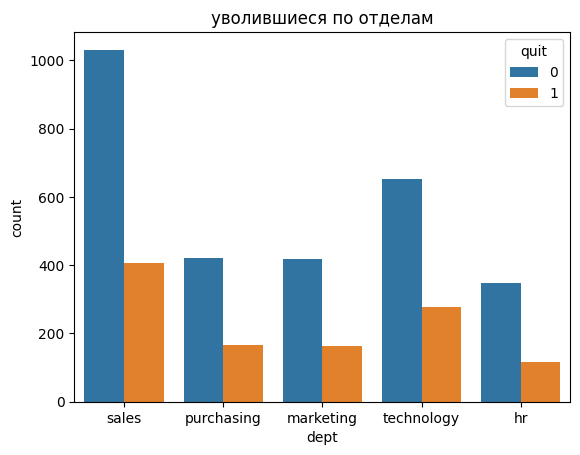

In [ ]:
ax = sns.countplot(data=train_df, x = 'dept', hue='quit');
ax.set_title('уволившиеся по отделам')

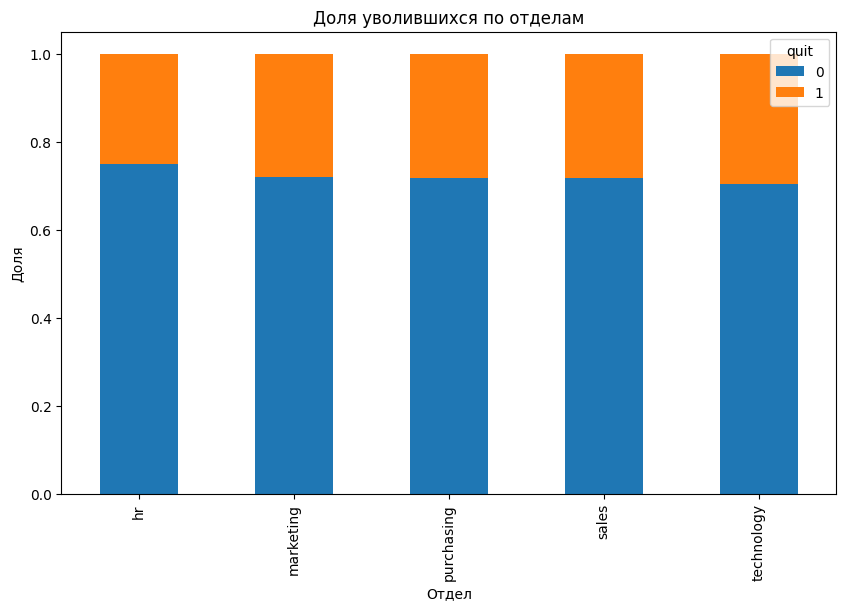

In [480]:
# код ревьюера

# Используем matplotlib с stacked=True 
# Группируем данные по отделам и статусу увольнения, считаем количество
grouped = train_df.groupby(['dept', 'quit']).size().unstack()

# Нормализуем данные по строкам (по отделам)
grouped_normalized = grouped.div(grouped.sum(axis=1), axis=0)

# Строим stacked bar plot
ax = grouped_normalized.plot(kind='bar', stacked=True, figsize=(10, 6))

# Добавляем заголовок и метки осей
ax.set_title('Доля уволившихся по отделам')
ax.set_ylabel('Доля')
ax.set_xlabel('Отдел')

plt.show()

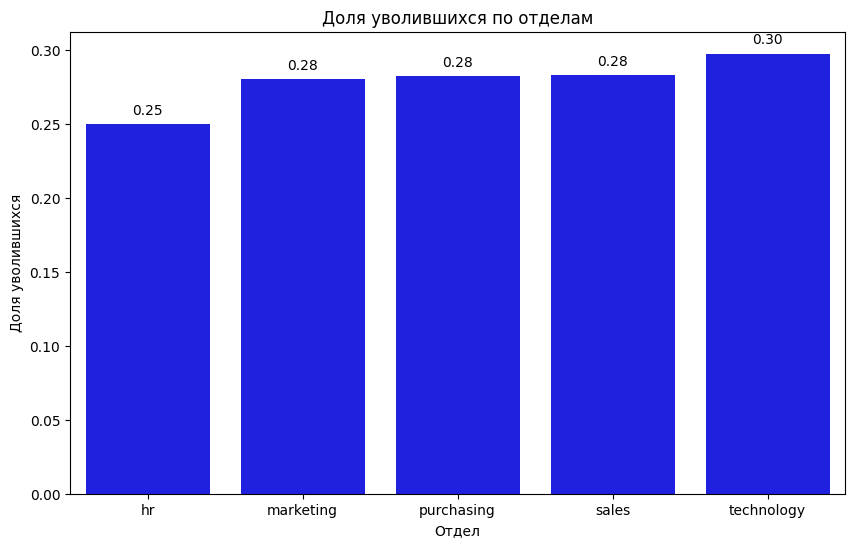

In [481]:
# код ревьюера
# Используем seabort c добавлением цифр

# Вычисляем долю уволившихся для каждого отдела
quit_ratio = train_df.groupby('dept')['quit'].mean().reset_index()
quit_ratio.columns = ['dept', 'quit_ratio']

# Построение графика
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=quit_ratio, x='dept', y='quit_ratio', color='blue')
ax.set_title('Доля уволившихся по отделам')
ax.set_ylabel('Доля уволившихся')
ax.set_xlabel('Отдел')

# Добавляем значения на столбцы
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points')

plt.show()

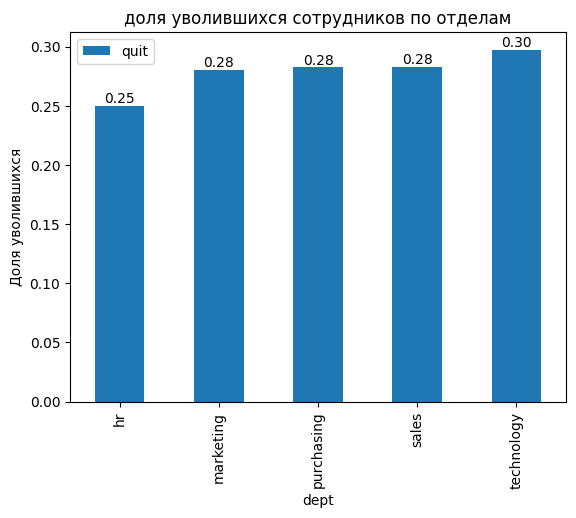

In [482]:
ax = train_df.pivot_table(index='dept', values='quit').plot.bar(title='доля уволившихся сотрудников по отделам')
ax.set_ylabel('Доля уволившихся')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

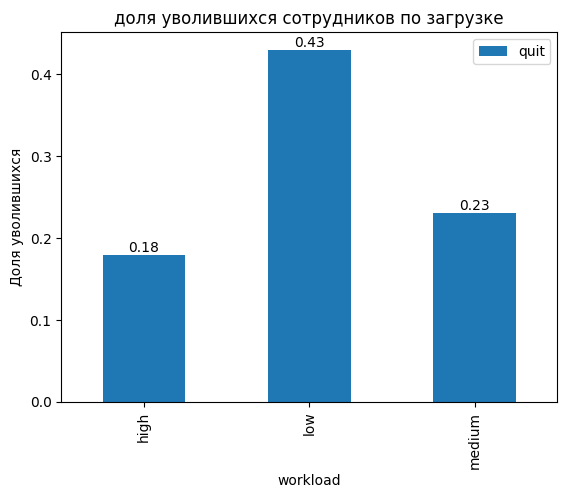

In [483]:
ax = train_df.pivot_table(index='workload', values='quit').plot.bar(title='доля уволившихся сотрудников по загрузке')
ax.set_ylabel('Доля уволившихся')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

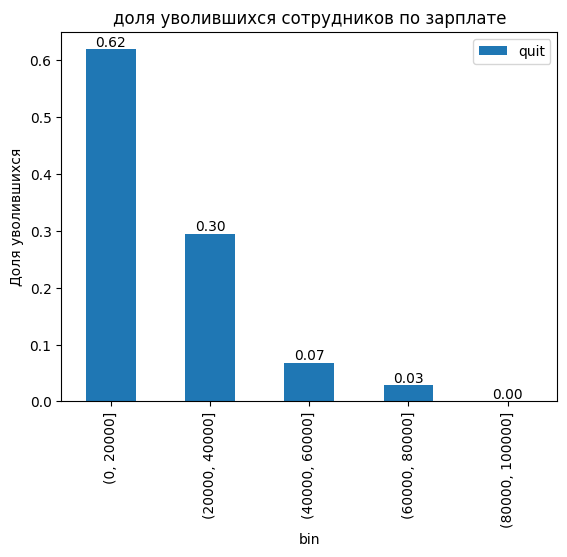

In [484]:
tmp_df = train_df.copy()
STEP=20000
tmp_df['bin'] = pd.cut(tmp_df.salary, range(0, max(tmp_df.salary+STEP), STEP))

ax = tmp_df.pivot_table(index='bin', values='quit').plot.bar(title='доля уволившихся сотрудников по зарплате')
ax.set_ylabel('Доля уволившихся')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

Исходя из проведённого ранее EDA и распределения уходов по отделам, портрет уволившегося получился таким:
- чуть чаще это сотрудник отдела Technology (30%), чуть реже - сотрудник HR (25%)
- чаще всего это джун (89% уволившихся)
- это средне и слабо загруженные сотрудники
    - вероятно, у активной молодёжи не так много шансов себя проявить, а ей это может быть важно
- за последний год не пересматривали з. п. (в отличии от тех, кто остался)
- нарушали контракт вдвое чаще, чем оставшиеся
- отработал в среднем год (в отличии от 4 лет у оставшихся)
- получил оценку руководителя 3 (в отличии от 4 лет у оставшихся)
- зарплата - одна из самых низких (у уволившегося в 1.5 раза ниже оставшегося, но это может объясняться тем, что среди них гораздо больше джунов)



<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

### 3.3.

Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверьте это утверждение: визуализируйте и сравните распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. Используйте данные с обоими целевыми признаками тестовой выборки.


Для начала нам придётся рассчитать job_satisfaction_rate для тестовой выборки второй задачи. Очевидно, что речь тут идёт именно про тестовую выборку второй задачи, т. к. в тестовой выборке первой задачи нет фичи quit.

In [485]:
quit_on_X_test_2 = test_df['quit']
X_test_2_tmp = test_df.drop(['id', 'quit'], axis=1)
job_satisfaction_rate_predicted_on_X_test_2 = \
    randomized_search_1.best_estimator_.predict(X_test_2_tmp)

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [486]:
df_tmp = pd.DataFrame( \
    data = {'job_satisfaction_rate':job_satisfaction_rate_predicted_on_X_test_2,
            'quit':quit_on_X_test_2})

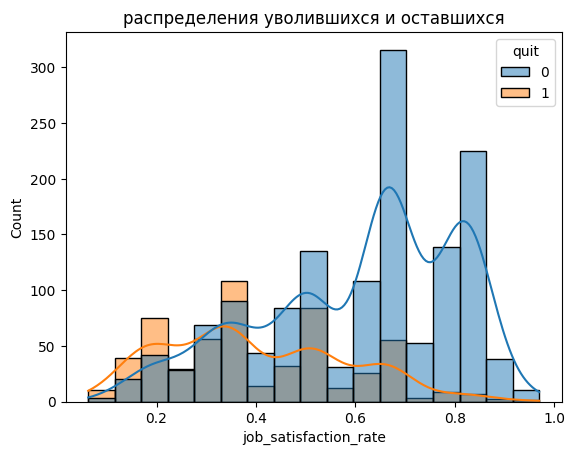

In [487]:
ax = sns.histplot(data=df_tmp, x = 'job_satisfaction_rate', hue='quit', kde=True);
ax.set_title('распределения уволившихся и оставшихся');

Из распределений видно, что у тех кто остался распределение уровня удовлетворённости смещено вправо (к более высоким оценкам), в у тех, кто ушёл - влево (к более низким).

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 4. Добавление нового входного признака
Допустим, job_satisfaction_rate и quit действительно связаны и вы получили необходимое значение метрики в первой задаче. Тогда добавьте job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.


In [488]:
train_df['job_satisfaction_rate'] = \
    randomized_search_1.best_estimator_ \
        .predict(train_df.drop(['id', 'quit'], axis=1))

X_train = train_df.drop(['quit', 'id'], axis=1)
y_train = train_df['quit']

In [489]:
test_df['job_satisfaction_rate'] = \
    randomized_search_1.best_estimator_ \
        .predict(test_df.drop(['id', 'quit'], axis=1))

X_test = test_df.drop(['quit', 'id'], axis=1)
y_test = test_df['quit']

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [490]:
train_df

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,0,0.634541
1,814010,sales,junior,medium,2,no,no,4,27600,0,0.825695
2,155091,purchasing,middle,medium,5,no,no,1,37200,0,0.373529
3,257132,sales,junior,medium,2,no,yes,3,24000,1,0.354056
4,910140,marketing,junior,medium,2,no,no,5,25200,0,0.759146
...,...,...,...,...,...,...,...,...,...,...,...
3995,588809,sales,junior,medium,4,no,no,3,26400,0,0.535037
3996,672059,sales,middle,high,9,no,no,4,52800,0,0.841506
3997,536432,purchasing,junior,low,2,no,yes,4,12000,1,0.527565
3998,692133,purchasing,middle,medium,2,no,no,4,33600,0,0.547610


In [491]:
test_df

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0,0.862515
1,686555,hr,junior,medium,1,no,no,4,30000,0,0.683503
2,467458,sales,middle,low,5,no,no,4,19200,0,0.657114
3,418655,sales,middle,low,6,no,no,4,19200,0,0.657103
4,789145,hr,middle,medium,5,no,no,5,40800,0,0.784443
...,...,...,...,...,...,...,...,...,...,...,...
1992,393147,marketing,junior,low,3,no,no,3,20400,1,0.518537
1993,109582,technology,middle,low,3,no,no,2,21600,1,0.151246
1994,305653,technology,junior,low,1,no,no,3,14400,1,0.223956
1995,160233,technology,middle,low,8,no,no,1,32400,0,0.522636


<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 5. Подготовка данных
Подготовьте признаки так же, как и в первой задаче: выполните подготовку в пайплайне, дополнив пайплайн предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.


Целевой признак - уволится ли сотрудник  удовлетворённости, значит мы решаем задачу классификации. Positive класс мы уже вручную закодировали как quit=1 (сотрудник уволился).

In [492]:
# ord_columns - уже задан выше (в первой задаче)

ohe_columns = ['dept']
ord_columns = [
    'level',
    'workload',
    'last_year_promo',
    'last_year_violations'
]
num_columns = ['employment_years',
               'supervisor_evaluation',
               'salary',
               'job_satisfaction_rate'
]

In [493]:
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
    )

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[['junior', 'middle', 'senior'],
                            ['low', 'medium', 'high'],
                            ['no', 'yes'],
                            ['no', 'yes']],     
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns),
    ], 
    remainder='passthrough'
) 

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 6. Обучение модели

Обучите как минимум три модели. Как минимум для двух из них подберите гиперпараметры. Проверьте качество лучшей модели.
Метрика оценки качества в этой задаче — ROC-AUC. 

Критерий успеха: ROC-AUC ≥ 0.91 на тестовой выборке. Напомним: отбор признаков часто помогает улучшить метрику.


In [494]:
%%time

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])


param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')],
        'models__max_depth': range(2, 4),
        'models__max_features': range(2, 4),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1',
            class_weight='balanced'
        )],
        'models__C': range(1, 3),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
    {
        'models': [SVC(
            random_state=RANDOM_STATE, 
            kernel='linear', probability=True, class_weight='balanced'
        )],
        'models__kernel': ['poly', 'rbf'],
        'models__degree': range(2, 5),
        'models__C': range(1, 3),
        'preprocessor__num': [StandardScaler(), 'passthrough']   
    }
]

randomized_search_2 = RandomizedSearchCV(
    pipe_final, 
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_iter=500,
    verbose = 3,
    n_jobs=-1
)
randomized_search_2.fit(X_train, y_train)
display('Лучшая модель и её параметры:', randomized_search_2.best_estimator_, )
display ('roc_auc лучшей модели на кроссвалидации:', randomized_search_2.best_score_)

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 42 is smaller than n_iter=500. Running 42 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 42 candidates, totalling 126 fits


'Лучшая модель и её параметры:'

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequ...
                                                                                  unknown_value=nan)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload',
                                                   'last_year_promo',
                                                   'last_year_violations']),
                                                 ('num', StandardScaler(),
                                                  ['employment_years',
                                                   'supervisor_evaluation',
                                                   'salary',
                                                   'job_satisfaction_rate'])])),
                ('models',
                 SVC(C=1, class_weight='balanced', kernel='poly',
                     probability=True, random_state=42))])

'roc_auc лучшей модели на кроссвалидации:'

0.9274160395318173

CPU times: total: 2.38 s
Wall time: 28.6 s


In [495]:
randomized_search_2.best_params_

{'preprocessor__num': StandardScaler(),
 'models__kernel': 'poly',
 'models__degree': 3,
 'models__C': 1,
 'models': SVC(class_weight='balanced', kernel='linear', probability=True, random_state=42)}

Оценим roc_auc на тестовой выборке:

In [496]:
y_pred = randomized_search_2.best_estimator_.predict_proba(X_test)[:, 1]
display(f"roc_auc = {roc_auc_score(y_test, y_pred)}")

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


'roc_auc = 0.9164717844433146'

На тестовой выборке всё не так радужно.

Попробуем отбор признаков:

In [497]:
%%time
# Предобработка данных через пайплайн без конечной модели
preprocessor = randomized_search_2.best_estimator_.named_steps['preprocessor']
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Извлечение лучшей модели из результатов RandomizedSearchCV
best_model = randomized_search_2.best_estimator_.named_steps['models']

X_test_preprocessed = pd.DataFrame(X_test_preprocessed)
X_train_preprocessed = pd.DataFrame(X_train_preprocessed)


all_feature_names = preprocessor.get_feature_names_out()

for i in range(len(X_test_preprocessed.columns)):
    selector = SelectKBest(f_classif, k=i+1)
    selector.fit(X_train_preprocessed, y_train)
    
    features_names = X_train_preprocessed.columns[selector.get_support(indices=True)]
    
    X_train_new = X_train_preprocessed[list(features_names)]
    X_test_new = X_test_preprocessed[list(features_names)]

    model = SVC(kernel = 'rbf', C=1, probability=True, 
                degree=3, random_state=RANDOM_STATE)
    model.fit(X_train_new, y_train)

    roc_auc_new = roc_auc_score(y_test, model.predict(X_test_new))

    display (f'iteration: {i}, roc_auc = {roc_auc_new}')

c:\Users\Papa\.conda\envs\practicum\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


'iteration: 0, roc_auc = 0.7642844743139856'

'iteration: 1, roc_auc = 0.6890243902439025'

'iteration: 2, roc_auc = 0.6743803241286098'

'iteration: 3, roc_auc = 0.8498468634915124'

...

'iteration: 8, roc_auc = 0.8715848078663807'

'iteration: 9, roc_auc = 0.8708879437548825'

'iteration: 10, roc_auc = 0.8762632211985566'

'iteration: 11, roc_auc = 0.8741354297122026'

CPU times: total: 24.4 s
Wall time: 25.3 s


К сожалению, отбор признаков не помог улучшить показатели.

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

## Шаг 7. Выводы
Сделайте промежуточные выводы о том, какая модель справилась лучше и почему.

Лучшие показатели у модели:
- SVC(C=1, probability=True, random_state=42)
- preprocessor__num': StandardScaler()
- models__kernel': 'rbf'
- models__degree': 3
- models__C': 1

 Это следует из пайпалайна.

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

# Общий вывод

Сформулируйте общий вывод:

Портрет уволившегося получился таким:
- чуть чаще это сотрудник отдела Technology, чуть реже - сотрудник HR
- чаще всего это джун (89% уволившихся)
- это средне и слабо загруженные сотрудники
    - вероятно, у активной молодёжи не так много шансов себя проявить, а ей это может быть важно
- за последний год не пересматривали з. п. (в отличии от тех, кто остался)
- нарушали контракт вдвое чаще, чем оставшиеся
- отработал в среднем год (в отличии от 4 лет у оставшихся)
- получил оценку руководителя 3 (в отличии от 4 лет у оставшихся)
- зарплата уволившегося в 1.5 раза ниже оставшегося (но это может объясняться тем, что среди них гораздо больше джунов)

Выявлены взамосвязи:
- оценка удовлетворённости <-> факт последующего увльнения 
- зарплата <-> нагрузка
- уровень удовлетворённости сотрудника <-> оценка руководителем
- зарплата <-> уровень должности
- длительность работы <-> уровень должности

Построенные модели смогут помочь в предсказании уровня удовлетворённости и риска ухода. Из показатели качества на тестовой выборке:
- модель, предсказывающая уровень удовлетворённости:
    - SMAPE : 12.40 (RandomForestRegressor)
- классификатор увольнения:
    - ROC_AUC: 0.92 (SVC)


<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

опишите задачу;

Первая задача — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника

Вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

Более подробное описание в задаче - в самом начале тетрадки.

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

опишите все этапы работы;

- Загружены данные
- Проведена предобработка данных
    - удалены пропуски
    - исправлена опечатка в данных
- Проведён исследовательский анализ данных
    - для классификатора проведено андерсэмплирование вследствие несбалансированности обучающей выборки
- Обучены 2 модели
- Подготовлены предложения для бизнеса

<div class="alert alert-secondary" style="background-color:#DCDCDC;color:black;">

добавьте выводы и дополнительные предложения для бизнеса.

- В будущем в признаки также нужно добавить сравнение зарплат соответствующего уровня с рынком. Он критически важен для модели и для корректных выводов и обычно должен быть у HR.
- Также в признаках пригодится размер последнего повышения.
- Молодых сотрудников нужно больше загружать работой и давать возможность себя проявить. Особенно в отделе Technology.
- Нужно по возможности повышать зарплату большему количеству сотрудников. 
- Также стоит повышать нематериальные стимулы. Для этого менеджеров среднего звена нужно направить на соответствующие тренинги.